In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy as sp
import math
import json
import neal
import joblib
import glob
import logging
import dimod
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from termcolor import colored
from timeit import default_timer as timer


from algorithms import logger, get_A, greedy, Linear, \
                       AugumentedLagrangian, Sampler, Result, relabel_subgraph_nodes, \
                       ProposedAlgorithm, MaxIndependentSet, DidNotConverge, PrintInfo
from algorithms import QuboTriU as Qubo

from enum import IntEnum
from dwave.system import FixedEmbeddingComposite
from dwave.samplers import SteepestDescentSolver
from dwave.system import DWaveSampler
from dimod.sampleset import SampleSet



class PenaltyType(IntEnum):
    TYPE1 = 1
    TYPE2 = 2
    TYPE3 = 3

class ProblemSize(IntEnum):
    SIZE40 = 40
    SIZE80 = 80
    SIZE100 = 100
    SIZE120 = 120
    SIZE140 = 140
    SIZE160 = 160


    
data_dir_base = '../../../biqbin/k-cluster/{}/{}'
solution_file = '../../solutions.html'
original_datafile_mask = '../../k-cluster_{}/{}.dat'

penalty_type = PenaltyType.TYPE1
problem_size = 40

def read_solutions_raw(filename):
    solutions = pd.read_html(filename, header=0)[0]
    
    old_columns = ['Instance', 'optimum', 'Instance.1', 'optimum.1', 'Instance.2',
           'optimum.2', 'Instance.3', 'optimum.3', 'Instance.4', 'optimum.4',
           'Instance.5', 'optimum.5']
    
    new_columns = ['instance_40', 'optimum_40', 'instance_80', 'optimum_80', 'instance_100',
           'optimum_100', 'instance_120', 'optimum_120', 'instance_140', 'optimum_140',
           'instance_160', 'optimum_160']

    return solutions.rename(columns=dict(zip(old_columns, new_columns)))

    

def get_A(filename):
    """Read adjacency matrix of a graph and cluster size

    Args:
        filename (_type_): _description_

    Returns:
        raw_data, adjacency_matrix, k
    """
    A_raw = np.loadtxt(filename, dtype=int, usecols=(0, 1))
    n, k = A_raw[0, :]
    
    A = np.zeros(shape=(n,n))
    A[A_raw[1:,0]-1, A_raw[1:,1]-1] = 1
    A = A+A.transpose()

    return A_raw, A, k


def get_solutions(solution_file):
    solutions_row = read_solutions_raw(solution_file)

    def gen_subdict(problem_size):
        for _, (instance, optimum) in solutions_row[[f'instance_{problem_size}', f'optimum_{problem_size}']].iterrows():
            original_datafile = original_datafile_mask.format(problem_size, instance)
            A_raw, A, k = get_A(original_datafile)
            yield instance, {'optimum': optimum, 'k': k, 'A': A}

    return {problem_size: dict(gen_subdict(problem_size)) for problem_size in ProblemSize}

solutions = get_solutions(solution_file)




In [3]:
solutions[80]

{'kcluster80_025_20_1': {'optimum': 94,
  'k': np.int64(20),
  'A': array([[0., 0., 0., ..., 1., 0., 1.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [1., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 1.],
         [1., 0., 0., ..., 0., 1., 0.]])},
 'kcluster80_025_20_2': {'optimum': 93,
  'k': np.int64(20),
  'A': array([[0., 1., 0., ..., 0., 0., 0.],
         [1., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 1., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]])},
 'kcluster80_025_20_3': {'optimum': 100,
  'k': np.int64(20),
  'A': array([[0., 1., 0., ..., 0., 0., 1.],
         [1., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 1.],
         [1., 0., 0., ..., 0., 1., 0.]])},
 'kcluster80_025_20_4': {'opti

In [4]:
data_dir_base = '../../../biqbin/k-cluster/{}/{}'
solution_file = '../../solutions.html'
original_datafile_mask = '../../k-cluster_{}/{}.dat'

penalty_type = PenaltyType.TYPE1
problem_size = 140

data_dir_mask = f'{data_dir_base.format(penalty_type, problem_size)}/*.json'
data_files = glob.glob(data_dir_mask)
data_files

['../../../biqbin/k-cluster/1/140/kcluster140_050_105_1.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_35_4.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_050_105_3.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_050_35_5.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_70_2.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_025_105_4.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_025_35_1.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_35_2.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_105_2.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_35_5.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_70_3.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_025_105_3.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_075_35_3.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_025_70_2.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_050_105_2.json',
 '../../../biqbin/k-cluster/1/140/kcluster140_025_105_5.json',
 

In [12]:
def ln_greedy(g, k):
    G_greedy, dmax, davg = greedy(g, k)
    return dmax, G_greedy.number_of_edges()


class AlgoGreedy:
    def __init__(self, g, k, **kwargs):
        self.g = g
        self.k = k
    def compute(self):
        g, dmax, davg = greedy(self.g, self.k)

        return Result(None, g, 'Greedy')


class AlgoLinearSA(Linear):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler()):
        dmax, greedy_num_edges = ln_greedy(g, k)
        initial_lambda = dmax
        super().__init__(
            g, k=k,
            method=Sampler(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, lambda_max_iterations=50,
            lambda_step=0.1
        )


class DefaultAlgoAugementedLagrangianSA(AugumentedLagrangian):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler()):
        initial_lambda = 0
        initial_mu=0.1
        super().__init__(
            g, k=k,
            method=Sampler(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, initial_mu=initial_mu, step=1.1, max_iterations=100
        )

class AlgoAugementedLagrangianSA(AugumentedLagrangian):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler()):
        dmax, greedy_num_edges = ln_greedy(g, k)
        initial_lambda = dmax
        initial_mu=0.1
        super().__init__(
            g, k=k,
            method=Sampler(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, initial_mu=initial_mu, step=1.1, max_iterations=50
        )


class AlgoAugementedLagrangianPenExactType1SA(AugumentedLagrangian):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler(), method=Sampler):
        dmax, greedy_num_edges = ln_greedy(g, k)
        initial_lambda = greedy_num_edges/2
        initial_mu=greedy_num_edges
        if initial_mu == 0:
            initial_mu = 1
        super().__init__(
            g, k=k,
            method=method(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, initial_mu=initial_mu, step=1.1, max_iterations=50
        )


class AlgoAugementedLagrangianPenExactType2SA(AugumentedLagrangian):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler(), method=Sampler):
        dmax, greedy_num_edges = ln_greedy(g, k)
        initial_lambda = 0
        initial_mu=greedy_num_edges*2
        if initial_mu == 0:
            initial_mu = 1


        print(method)
        
        super().__init__(
            g, k=k,
            method=method(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, initial_mu=initial_mu, step=1.1, max_iterations=50
        )


class SamplerPP(Sampler):
    def __init__(self, sampler, num_reads):
        super().__init__(sampler, num_reads)
    def compute(self, Q):
        
        self.print_debug()

        solver_greedy = SteepestDescentSolver()
        bqm = dimod.BQM.from_qubo(Q)
        sampleset = self.sampler.sample(bqm, num_reads = self.num_reads)
        sampleset = solver_greedy.sample(bqm, initial_states=sampleset)
        
        X = sampleset.first.sample
        value = sampleset.first.energy
        x = np.zeros(len(X), dtype=int)
        for i, v in X.items():
            x[i] = v
        return {'x': x, 'value': value, 'cardinality': sum(x), 'sampleset': sampleset}



class AlgoAugementedLagrangianPenExactType1SAPP(AlgoAugementedLagrangianPenExactType1SA):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler(), method=SamplerPP):
        super().__init__(
            g, k=k,
            num_reads=num_reads,
            sampler=sampler,
            method=method
        )


class AlgoAugementedLagrangianPenExactType2SAPP(AlgoAugementedLagrangianPenExactType2SA):
    def __init__(self, g, k, num_reads=10, sampler=neal.SimulatedAnnealingSampler(), method=SamplerPP):
        super().__init__(
            g, k=k,
            num_reads=num_reads,
            sampler=sampler,
            method=method
        )



class ResultEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.bool):
            return bool(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, nx.classes.graph.Graph):
            return nx.node_link_data(obj, edges='edges')
        elif isinstance(obj, SampleSet):
            return obj.to_serializable()
        else:
            return super(MyEncoder, self).default(obj)


In [7]:
from termcolor import colored
import time
import os
from pathlib import Path


# Source - https://stackoverflow.com/a
# Posted by mgilson, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-26, License - CC BY-SA 3.0




def compute(out_file_name_base, algorithms, number_of_reads, sizes):
    for get_algorithm in algorithms:
        for num_reads in number_of_reads:
            for size in sizes:
                print()
                print(f'size={size}')
                instances = solutions[size].keys()
                for instance in instances:
                    data = solutions[size][instance] 
            
                    k = data['k']
                    A = data['A']
                    optimum = k*(k-1)/2 - data['optimum']
                    print()
                    print(f'instance={instance}, optimum={optimum}')
    
                    #continue
                    
                    g_complement = nx.from_numpy_array(A)
                    g = nx.complement(g_complement)    
            
                    time_b = time.time()
                    algorithm = get_algorithm(g=g, k=k, num_reads=num_reads)
                    result = algorithm.compute().summary()
                    comp_time = time.time() - time_b
            
                    computed_g = result['g']
                    computed_val = computed_g.number_of_edges()
                    computed_cardinality = computed_g.number_of_nodes()
            
                    is_optimal = computed_val == optimum
                    algorithm_name = type(algorithm).__name__
            
                    super_summary = {
                        'instance': instance,
                        'algorithm': algorithm_name,
                        'optimum': optimum, 
                        'computed_val': computed_val, 
                        'is_optimal': is_optimal,
                        'computed_cardinality': computed_cardinality,
                        'time': comp_time,
                    }
            
                    result['super_summary'] = super_summary
            
                    out_file_name = out_file_name_base.format(algorithm_name, num_reads, size, instance)
                    Path(os.path.dirname(out_file_name)).mkdir(parents=True, exist_ok=True)
                    
                    print(f'Writting {out_file_name} ...')
                    with open(out_file_name, 'w') as f:
                        json.dump(result, f, indent=4, cls=ResultEncoder)
                    print('Done.')
            
            
                    if is_optimal:
                        print_color = 'green'
                    else:
                        print_color = 'red'
            
                    print(colored(f'{algorithm}: num_edges={computed_val}', print_color))
                    print(f'{algorithm_name}, Computation finished in {comp_time} seconds.')
                    print(out_file_name)
            


In [107]:
out_file_name_base = 'results/{}/num_reads_{}/{}/{}.json'

In [108]:
sizes = solutions.keys()
number_of_reads = [10]
algorithms = [
    DefaultAlgoAugementedLagrangianSA
]

compute(out_file_name_base, algorithms, number_of_reads, sizes)



size=40

instance=kcluster40_025_10_1, optimum=16.0
Writting results/DefaultAlgoAugementedLagrangianSA/num_reads_10/40/kcluster40_025_10_1.json ...
Done.
DefaultAlgoAugementedLagrangianSA(g=(40, 597),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,initial_mu=0.1, step=1.1, max_iterations=100))
lambdai=3.9225565010000008
mui=0.23579476910000013
number_of_iterations=10: num_edges=16
DefaultAlgoAugementedLagrangianSA, Computation finished in 0.08022618293762207 seconds.
results/DefaultAlgoAugementedLagrangianSA/num_reads_10/40/kcluster40_025_10_1.json

instance=kcluster40_025_10_2, optimum=15.0
Writting results/DefaultAlgoAugementedLagrangianSA/num_reads_10/40/kcluster40_025_10_2.json ...
Done.
DefaultAlgoAugementedLagrangianSA(g=(40, 562),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,initial_mu=0.1, step=1.1, max_iterations=100))
lambdai=3.9350975010000013
mui=0.2357947691

In [109]:
algorithms = [
    'AlgoAugementedLagrangianSA',
    'DefaultAlgoAugementedLagrangianSA',
    'AlgoLinearSA'
]

algorithms = [
    'AlgoGreedy',
    'AlgoAugementedLagrangianSA',
    'DefaultAlgoAugementedLagrangianSA',
    'AlgoLinearSA',
    'AlgoAugementedLagrangianPenExactType1SA', 
    'AlgoAugementedLagrangianPenExactType2SA',
    'AlgoAugementedLagrangianPenExactType1SAPP', 
    'AlgoAugementedLagrangianPenExactType2SAPP', 
]


sizes = [40, 80, 100, 120, 140, 160]

file_base = 'results/{}/num_reads_{}/{}/*.json'

num_reads_list = [10]

def flatten_dict(d, prefix='', level=0):
    for i,j in d.items():
        if isinstance(j, dict):
            yield from flatten_dict(j, f'{prefix}{i}_', level+1)
        else:
            yield f'{prefix}{i}', j


def get_result_data(file_base, algos, sizes, num_reads_list):
    for algo in algos:
        for size in sizes:
            for num_read in num_reads_list:
                result_files = glob.glob(file_base.format(algo, num_read, size))
                for i in result_files:
                    with open(i) as f:
                        result = json.load(f)
                    try:
                        number_of_iterations = result['additional_info']['algo_summary']['number_of_iterations']
                    except:
                        number_of_iterations = None

                    yield {'algorithm': algo, 'size': size, 'number_of_iterations': number_of_iterations, 'num_reads': num_read, **dict(flatten_dict(result['super_summary']))}


res = pd.DataFrame(get_result_data(file_base, algorithms, sizes,  [10, 100, 1000, 'None']))
#res_exact_penalty = pd.DataFrame(get_result_data(file_base, algorithms_exact_penalty, sizes, [10, 100, 1000]))

file_base_qpu = 'results/Advantage2_system2.1/{}/num_reads_{}/{}/*.json'

number_of_reads = [500]
sizes = [40]
algorithms_qpu = [
    'AlgoLinearQPU',
    'AlgoLinearQPUPP',
]

res_qpu = pd.DataFrame(get_result_data(file_base_qpu, algorithms_qpu, sizes,  number_of_reads))


In [110]:
res_qpu

,algorithm,size,number_of_iterations,num_reads,instance,optimum,computed_val,is_optimal,computed_cardinality,time
0,AlgoLinearQPU,40,None,500,kcluster40_075_20_4,19.0,21,False,20,4.891421
1,AlgoLinearQPU,40,None,500,kcluster40_025_10_4,18.0,21,False,10,0.612904
2,AlgoLinearQPU,40,None,500,kcluster40_025_30_4,301.0,307,False,30,2.102395
3,AlgoLinearQPU,40,None,500,kcluster40_075_20_1,22.0,25,False,20,2.098998
4,AlgoLinearQPU,40,None,500,kcluster40_075_10_5,0.0,1,False,10,1.781898
...,...,...,...,...,...,...,...,...,...,...
85,AlgoLinearQPUPP,40,None,500,kcluster40_075_10_1,0.0,0,True,10,15.988750
86,AlgoLinearQPUPP,40,None,500,kcluster40_050_10_1,5.0,5,True,10,0.925465
87,AlgoLinearQPUPP,40,None,500,kcluster40_075_30_1,86.0,86,True,30,1.322146
88,AlgoLinearQPUPP,40,None,500,kcluster40_025_10_5,19.0,19,True,10,2.254101


In [111]:
res['err'] = (res['computed_val']-res['optimum'])# /res['optimum']
res_qpu['err'] = (res_qpu['computed_val']-res_qpu['optimum'])# /res_qpu['optimum']

#res_exact_penalty['err'] = 100*(res_exact_penalty['computed_val']-res_exact_penalty['optimum'])/res_exact_penalty['optimum']

In [112]:
res.groupby(['algorithm', 'size', 'num_reads'])[['number_of_iterations', 'time', 'is_optimal', 'err']].mean().head(60)

number_of_iterations  \
algorithm                                 size num_reads                         
AlgoAugementedLagrangianPenExactType1SA   40   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          80   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.066667   
                                          100  10                     1.044444   
                                               100                    1.022222   
                                               1000                   1.000000   
                                          120  10                     1.066667   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          140  10                     1.022222   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          160  10                     1.088889   
                                               100                    1.022222   
                                               1000                   1.000000   
AlgoAugementedLagrangianPenExactType1SAPP 40   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          80   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          100  10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          120  10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          140  10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          160  10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
AlgoAugementedLagrangianPenExactType2SA   40   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          80   10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          100  10                     1.000000   
                                               100                    1.000000   
                                               1000                   1.000000   
                                          120  10                     1.000000   
                                               100                    1.000000   
                                        

In [113]:
res_qpu.groupby(['algorithm', 'size', 'num_reads'])[['number_of_iterations', 'time', 'is_optimal', 'err']].mean().head(50)

,,,number_of_iterations,time,is_optimal,err
algorithm,size,num_reads,,,,
AlgoLinearQPU,40,500,NaN,2.119894,0.000000,3.711111
AlgoLinearQPUPP,40,500,NaN,4.293474,0.977778,0.022222


In [117]:
mask = res['algorithm'].isin(['DefaultAlgoAugementedLagrangianSA', 'AlgoAugementedLagrangianSA', 'AlgoGreedy', 'AlgoLinearSA'])

res[mask].groupby(['algorithm', 'size', 'num_reads'])[['number_of_iterations', 'time', 'is_optimal', 'err']].mean().head(60)

number_of_iterations  \
algorithm                         size num_reads                         
AlgoAugementedLagrangianSA        40   10                     2.377778   
                                  80   10                     3.977778   
                                  100  10                     1.644444   
                                  120  10                     4.955556   
                                  140  10                     3.933333   
                                  160  10                     5.711111   
AlgoGreedy                        40   None                        NaN   
                                  80   None                        NaN   
                                  100  None                        NaN   
                                  120  None                        NaN   
                                  140  None                        NaN   
                                  160  None                        NaN   
AlgoLinearSA                      40   10                          NaN   
                                  80   10                          NaN   
                                  100  10                          NaN   
                                  120  10                          NaN   
                                  140  10                          NaN   
                                  160  10                          NaN   
DefaultAlgoAugementedLagrangianSA 40   10                    11.688889   
                                  80   10                    14.800000   
                                  100  10                    13.666667   
                                  120  10                    16.000000   
                                  140  10                    15.244444   
                                  160  10                    17.066667   

                                                      time  is_optimal  \
algorithm                         size num_reads                         
AlgoAugementedLagrangianSA        40   10         0.018047    1.000000   
                                  80   10         0.096092    1.000000   
                                  100  10         0.049731    1.000000   
                                  120  10         0.491093    1.000000   
                                  140  10         0.470847    1.000000   
                                  160  10         0.848624    1.000000   
AlgoGreedy                        40   None       0.000441    0.511111   
                                  80   None       0.001891    0.177778   
                                  100  None       0.002351    0.111111   
                                  120  None       0.003417    0.044444   
                                  140  None       0.007549    0.133333   
                                  160  None       0.006121    0.088889   
AlgoLinearSA                      40   10         0.059526    1.000000   
                                  80   10         0.178102    0.933333   
                                  100  10         0.140347    1.000000   
                                  120  10         0.541569    0.977778   
                                  140  10         0.779648    0.955556   
                                  160  10         1.249614    0.977778   
DefaultAlgoAugementedLagrangianSA 40   10         0.092027    1.000000   
                                  80   10         0.332330    1.000000   
                                  100  10         0.454528    1.000000   
                                  120  10         1.640002    1.000000   
                                  140  10         2.196238    1.000000   
                                  160  10         2.854378    1.000000   

                                                       err  
algorithm                         size num_reads            
AlgoAugementedLagrangianSA        40   10         0.000000  
                 

In [104]:


res[mask].groupby(['algorithm', 'size', 'num_reads'])[['number_of_iterations', 'time', 'is_optimal', 'err']].count().head(60)

number_of_iterations  time  \
algorithm                         size num_reads                               
DefaultAlgoAugementedLagrangianSA 40   10                           45    45   
                                  80   10                           45    45   
                                  100  10                           45    45   
                                  120  10                           45    45   
                                  140  10                           45    45   
                                  160  10                           45    45   

                                                  is_optimal  err  
algorithm                         size num_reads                   
DefaultAlgoAugementedLagrangianSA 40   10                 45   45  
                                  80   10                 45   45  
                                  100  10                 45   45  
                                  120  10                 45   45  
                                  140  10                 45   45  
                                  160  10                 45   45

In [90]:

sizes = solutions.keys()
number_of_reads = [None]
algorithms = [
    AlgoGreedy,
]

compute(out_file_name_base, algorithms, number_of_reads, sizes)



size=40

instance=kcluster40_025_10_1, optimum=16.0
Writting results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_1.json ...
Done.
<__main__.AlgoGreedy object at 0x7f8faa923080>: num_edges=17
AlgoGreedy, Computation finished in 0.0005319118499755859 seconds.
results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_1.json

instance=kcluster40_025_10_2, optimum=15.0
Writting results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_2.json ...
Done.
<__main__.AlgoGreedy object at 0x7f8fa82a3e00>: num_edges=17
AlgoGreedy, Computation finished in 0.0005154609680175781 seconds.
results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_2.json

instance=kcluster40_025_10_3, optimum=18.0
Writting results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_3.json ...
Done.
<__main__.AlgoGreedy object at 0x7f8fa83d38c0>: num_edges=20
AlgoGreedy, Computation finished in 0.0005629062652587891 seconds.
results/AlgoGreedy/num_reads_None/40/kcluster40_025_10_3.json

instance=kcluster40_025_10_4, optimum=18.0
Wr

In [96]:
algorithms = [
#    AlgoLinearSA,
    AlgoAugementedLagrangianSA,
]

number_of_reads = [10]
sizes = [140, 160]

compute(out_file_name_base, algorithms, number_of_reads, sizes)



size=140

instance=kcluster140_025_35_1, optimum=336.0
Writting results/AlgoAugementedLagrangianSA/num_reads_10/140/kcluster140_025_35_1.json ...
Done.
AlgoAugementedLagrangianSA(g=(140, 7297),k=35, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=22,initial_mu=0.1, step=1.1, max_iterations=50))
lambdai=22
mui=0.1
number_of_iterations=1: num_edges=336
AlgoAugementedLagrangianSA, Computation finished in 0.13077020645141602 seconds.
results/AlgoAugementedLagrangianSA/num_reads_10/140/kcluster140_025_35_1.json

instance=kcluster140_025_35_2, optimum=332.0
Writting results/AlgoAugementedLagrangianSA/num_reads_10/140/kcluster140_025_35_2.json ...
Done.
AlgoAugementedLagrangianSA(g=(140, 7297),k=35, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=21,initial_mu=0.1, step=1.1, max_iterations=50))
lambdai=21
mui=0.1
number_of_iterations=1: num_edges=332
AlgoAugementedLagrangianSA, Computation finis

In [ ]:
algorithms = [
    AlgoAugementedLagrangianPenExactType1SA, 
    AlgoAugementedLagrangianPenExactType2SA,
    AlgoAugementedLagrangianPenExactType1SAPP,
    AlgoAugementedLagrangianPenExactType2SAPP
]

number_of_reads = [10, 100, 1000]
sizes = solutions.keys()

compute(out_file_name_base, algorithms, number_of_reads, sizes)



size=40

instance=kcluster40_025_10_1, optimum=16.0
Writting results/AlgoAugementedLagrangianPenExactType1SA/num_reads_10/40/kcluster40_025_10_1.json ...
Done.
AlgoAugementedLagrangianPenExactType1SA(g=(40, 597),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=8.5,initial_mu=17, step=1.1, max_iterations=50))
lambdai=8.5
mui=17
number_of_iterations=1: num_edges=24
AlgoAugementedLagrangianPenExactType1SA, Computation finished in 0.013791084289550781 seconds.
results/AlgoAugementedLagrangianPenExactType1SA/num_reads_10/40/kcluster40_025_10_1.json

instance=kcluster40_025_10_2, optimum=15.0
Writting results/AlgoAugementedLagrangianPenExactType1SA/num_reads_10/40/kcluster40_025_10_2.json ...
Done.
AlgoAugementedLagrangianPenExactType1SA(g=(40, 562),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=8.5,initial_mu=17, step=1.1, max_iterations=50))
lambdai=8.5
mui=17
number_of_iterations

In [73]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.bool):
            return bool(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, nx.classes.graph.Graph):
            return nx.node_link_data(obj, edges='edges')
        elif isinstance(obj, SampleSet):
            return obj.to_serializable()
        else:
            return super(MyEncoder, self).default(obj)

with open('test.json', 'w') as f:
    json.dump(result, f, indent=4, cls=MyEncoder)


with open('test.json') as f:
    data = json.load(f)


In [71]:
result

{'g': <networkx.classes.graph.Graph at 0x7f8faabde450>,
 'sampler_response': None,
 'additional_info': {},
 'algorithm': 'Greedy',
 'super_summary': {'algorithm': 'AlgoGreedy',
  'optimum': np.float64(336.0),
  'computed_val': 345,
  'is_optimal': np.False_,
  'computed_cardinality': 35,
  'time': 0.006693124771118164}}

In [49]:
result.summary()

{'g': <networkx.classes.graph.Graph at 0x7f8fb0ff9e50>,
 'sampler_response': {'x': array([0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
         1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
         0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
         0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 1, 1, 0, 0]),
  'value': np.float64(-216913.0),
  'cardinality': np.int64(35),
  'sampleset': SampleSet(rec.array([([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0

In [43]:
type(result.summary()['sampler_response']['sampleset'])

dimod.sampleset.SampleSet

In [18]:
result.summary()['additional_info']['algo_summary']['qubo']

{'Q': [array([[-12075.,    346.,    346., ...,    346.,    346.,    346.],
         [     0., -12075.,    346., ...,    346.,    345.,    346.],
         [     0.,      0., -12075., ...,    345.,    345.,    346.],
         ...,
         [     0.,      0.,      0., ..., -12075.,    345.,    346.],
         [     0.,      0.,      0., ...,      0., -12075.,    346.],
         [     0.,      0.,      0., ...,      0.,      0., -12075.]])],
 'lambda': [172.5],
 'mu_half': [345],
 'norm_Q': [146887.51811164897]}

In [59]:
type(algorithm).__name__

'AlgoAugementedLagrangianPenExactType1'

In [57]:
print(type(algorithm))

<class '__main__.AlgoAugementedLagrangianPenExactType1'>


In [5]:
get_algorithm = AlgoLinear

n_opt_greedy = 0
n_opt_1 = 0
n_opt_2 = 0
n_opt_3 = 0
n_opt_qpu = 0

def ln_greedy(g, k):
    G_greedy, dmax, davg = greedy(g, k)
    return dmax, G_greedy.number_of_edges()

for i in data_files:
    with open(i) as f:
        data = json.load(f)


    Q_data = data["qubo"]["data"]
    Q_row = data["qubo"]["row"]
    Q_col = data["qubo"]["col"]
    Q_shape = data["qubo"]["shape"]
    
    Q = sp.sparse.coo_matrix((Q_data, (Q_row, Q_col)), shape=Q_shape).toarray()
    offset = data["offset"]
    k = data["info"]["k"]
    l = data["info"]["lambda"]
    mu = data["info"]["mu"]
    instance = data['info']['instance']



    aaaa


    embeeding_file = f'{embedding_base.format(problem_size)}/{instance}.json'
    with open(embeeding_file) as f:
        emb = json.load(f)

    #bla

    emb = {int(k): v for k, v in emb.items()}

    A = solutions[problem_size][instance]['A']
    optimum = k*(k-1)/2 - solutions[problem_size][instance]['optimum']
#
    print(f'instance={instance}')
    print(f'lambda={l}, mu={mu}')
    
    g_complement = nx.from_numpy_array(A)
    g = nx.complement(g_complement)
#    G_greedy, dmax, davg = greedy(g, k)

#    print(instance, dmax)

    cardysm = [k-1, k-2, k-3]
    cardysp = [k+1, k+2, k+3]
    J = [1, 2, 3]

    cardysm = [k-1]
    cardysp = [k+1]
    J = [1]

    
    #print(f'\nSolving instance={instance}, optimum={optimum}, k={cardysm, cardysp} ...')
    #print('Computing mk ...')
    
    lk, greedy_sol = ln_greedy(g, k)
    lambdasm = [l_greedy(g, i) for i in cardysm]
    lambdasp = [l_greedy(g, i) for i in cardysp]
    mkm = []
    mkp = []
    mk_all = get_algorithm(g=g, k=k, initial_lambda=lk, num_reads=10).compute()
    mk = mk_all['g'].number_of_edges()
    for l,kk in zip(lambdasm, cardysm):
        mkm.append(get_algorithm(g=g, k=kk, initial_lambda=l, num_reads=10).compute()['g'].number_of_edges())
    for l,kk in zip(lambdasp, cardysp):
        mkp.append(get_algorithm(g=g, k=kk, initial_lambda=l, num_reads=10).compute()['g'].number_of_edges())
    #print('Done')

    Ak = max((mk-np.asarray(mkm))/np.asarray(J))
    Bk = min((np.asarray(mkp)-mk)/np.asarray(J))
    d = Bk-Ak
    print(Ak, Bk)
    _l = (Ak+Bk)/2
    if d < 0:
        _mu = ceil(-d/2)
    elif d == 0:
        _mu = 1
    else:
        _mu = 0

    print(f'lambda={_l}, mu={_mu}')
    print(f'lambda_lemma={lk}')
    
    print(mk_all)
    print('==============================================================')

    mk_all_2 = AlgoLinear(g=g, k=k, initial_lambda=_l).compute()
    mk_all_3 = AlgoAugementedLagrangian(g=g, k=k, initial_lambda=_l, initial_mu=2*_mu if _mu > 0 else 0.1).compute()
  

#    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=1000, sampler=QpuSamplerGreedyPost(region, chip_id, emb, annealing_time=200)).compute()
    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=100, sampler=QpuSamplerGreedyPost(region, chip_id, emb, annealing_time=20)).compute()
#    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=None, sampler=DwaveSamplerGreedy()).compute()
   
    mk_2 = mk_all_2['g'].number_of_edges()
    mk_3 = mk_all_3['g'].number_of_edges()
    mk_qpu = mk_all_qpu['g'].number_of_edges()
    
    print(mk_all_2)
    print(mk_all_3)
    print('qpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpu')
    print(mk_all_qpu)
    print('**********************************************************')
    print(f'{optimum} / optimum')
    print(f'{greedy_sol} / greedy_sol')
    print(f'{mk} / mk')
    print(f'{mk_2} / mk_2')
    print(f'{mk_3} / mk_3')
    print(f'{mk_qpu} / mk_qpu')
    print('**********************************************************')


    if optimum != greedy_sol:
        n_opt_greedy += 1
    if optimum != mk:
        n_opt_1 += 1
    if optimum != mk_2:
        n_opt_2 += 1
    if optimum != mk_3:
        n_opt_3 += 1
    if optimum != mk_qpu:
        n_opt_qpu += 1
    #assert mk == mk_2
    #break
print()
print(f'n_opt_mk={n_opt_1}')
print(f'n_opt_mk_2={n_opt_2}')
print(f'n_opt_mk_3={n_opt_3}')
print(f'n_opt_qpu={n_opt_qpu}')
print(f'n_opt_greedy={n_opt_greedy}')

NameError: name 'aaaa' is not defined

In [6]:
offset

5722.5

In [7]:
l

54.5

In [70]:




embedding_base = 'embedding/Advantage2_system2.1/{}'




#sampler = FixedEmbeddingComposite(DWaveSampler(region="eu-central-1", solver=sampler_properties['properties']['chip_id']), emb)
#sampleset = sampler.sample(bqm, num_reads=1000, annealing_time=200, chain_strength=15, return_embedding=True)
#solver_greedy = SteepestDescentSolver()
#sampleset_pp = solver_greedy.sample(bqm, initial_states=sampleset)

class QpuSamplerGreedyPost:
    def __init__(self, region, solver, emb, annealing_time):
        #sampler = FixedEmbeddingComposite(DWaveSampler(region="eu-central-1", solver=sampler_properties['properties']['chip_id']), emb)
        self.sampler = FixedEmbeddingComposite(DWaveSampler(region=region, solver=solver), emb)
        self.annealing_time = annealing_time
    def sample(self, bqm, num_reads):
        sampleset = self.sampler.sample(bqm, num_reads=num_reads, annealing_time=self.annealing_time, chain_strength=15, return_embedding=True)
        solver_greedy = SteepestDescentSolver()
        sampleset_pp = solver_greedy.sample(bqm, initial_states=sampleset)
        return sampleset_pp
    
class DwaveSamplerGreedy:
    def __init__(self):
        #sampler = FixedEmbeddingComposite(DWaveSampler(region="eu-central-1", solver=sampler_properties['properties']['chip_id']), emb)
        self.sampler = SteepestDescentSolver()
    def sample(self, bqm, num_reads):
        solver_greedy = SteepestDescentSolver()
        return self.sampler.sample(bqm)


sampler_filename = f'sampler_Advantage2_system2.1.json'
with open(sampler_filename) as f:
    sampler_properties = json.load(f)


chip_id = sampler_properties['properties']['chip_id']
region="eu-central-1"



class AlgoLinear(Linear):
    def __init__(self, g, k, initial_lambda, num_reads=10, sampler=neal.SimulatedAnnealingSampler()):
        super().__init__(
            g, k=k,
            method=Sampler(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, lambda_max_iterations=50,
            lambda_step=0.1
        )

class AlgoAugementedLagrangian(AugumentedLagrangian):
    def __init__(self, g, k, initial_lambda, initial_mu=0.1, num_reads=10, sampler=neal.SimulatedAnnealingSampler()):
        super().__init__(
            g, k=k,
            method=Sampler(sampler, num_reads=num_reads),
            result=Result,
            initial_lambda=initial_lambda, initial_mu=initial_mu, step=1.1, max_iterations=50
        )


In [71]:
from math import ceil

get_algorithm = AlgoLinear

n_opt_greedy = 0
n_opt_1 = 0
n_opt_2 = 0
n_opt_3 = 0
n_opt_qpu = 0

def ln_greedy(g, k):
    G_greedy, dmax, davg = greedy(g, k)
    return dmax, G_greedy.number_of_edges()

for i in data_files:
    with open(i) as f:
        data = json.load(f)


    Q_data = data["qubo"]["data"]
    Q_row = data["qubo"]["row"]
    Q_col = data["qubo"]["col"]
    Q_shape = data["qubo"]["shape"]
    
    Q = sp.sparse.coo_matrix((Q_data, (Q_row, Q_col)), shape=Q_shape).toarray()
    offset = data["offset"]
    k = data["info"]["k"]
    l = data["info"]["lambda"]
    mu = data["info"]["mu"]
    instance = data['info']['instance']


    embeeding_file = f'{embedding_base.format(problem_size)}/{instance}.json'
    with open(embeeding_file) as f:
        emb = json.load(f)

    #bla

    emb = {int(k): v for k, v in emb.items()}

    A = solutions[problem_size][instance]['A']
    optimum = k*(k-1)/2 - solutions[problem_size][instance]['optimum']
#
    print(f'instance={instance}')
    print(f'lambda={l}, mu={mu}')
    
    g_complement = nx.from_numpy_array(A)
    g = nx.complement(g_complement)
#    G_greedy, dmax, davg = greedy(g, k)

#    print(instance, dmax)

    cardysm = [k-1, k-2, k-3]
    cardysp = [k+1, k+2, k+3]
    J = [1, 2, 3]

    cardysm = [k-1]
    cardysp = [k+1]
    J = [1]

    
    #print(f'\nSolving instance={instance}, optimum={optimum}, k={cardysm, cardysp} ...')
    #print('Computing mk ...')
    
    lk, greedy_sol = ln_greedy(g, k)
    lambdasm = [l_greedy(g, i) for i in cardysm]
    lambdasp = [l_greedy(g, i) for i in cardysp]
    mkm = []
    mkp = []
    mk_all = get_algorithm(g=g, k=k, initial_lambda=lk, num_reads=10).compute()
    mk = mk_all['g'].number_of_edges()
    for l,kk in zip(lambdasm, cardysm):
        mkm.append(get_algorithm(g=g, k=kk, initial_lambda=l, num_reads=10).compute()['g'].number_of_edges())
    for l,kk in zip(lambdasp, cardysp):
        mkp.append(get_algorithm(g=g, k=kk, initial_lambda=l, num_reads=10).compute()['g'].number_of_edges())
    #print('Done')

    Ak = max((mk-np.asarray(mkm))/np.asarray(J))
    Bk = min((np.asarray(mkp)-mk)/np.asarray(J))
    d = Bk-Ak
    print(Ak, Bk)
    _l = (Ak+Bk)/2
    if d < 0:
        _mu = ceil(-d/2)
    elif d == 0:
        _mu = 1
    else:
        _mu = 0

    print(f'lambda={_l}, mu={_mu}')
    print(f'lambda_lemma={lk}')
    
    print(mk_all)
    print('==============================================================')

    mk_all_2 = AlgoLinear(g=g, k=k, initial_lambda=_l).compute()
    mk_all_3 = AlgoAugementedLagrangian(g=g, k=k, initial_lambda=_l, initial_mu=2*_mu if _mu > 0 else 0.1).compute()
  

#    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=1000, sampler=QpuSamplerGreedyPost(region, chip_id, emb, annealing_time=200)).compute()
    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=100, sampler=QpuSamplerGreedyPost(region, chip_id, emb, annealing_time=20)).compute()
#    mk_all_qpu = AlgoLinear(g=g, k=k, initial_lambda=_l, num_reads=None, sampler=DwaveSamplerGreedy()).compute()
   
    mk_2 = mk_all_2['g'].number_of_edges()
    mk_3 = mk_all_3['g'].number_of_edges()
    mk_qpu = mk_all_qpu['g'].number_of_edges()
    
    print(mk_all_2)
    print(mk_all_3)
    print('qpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpuqpu')
    print(mk_all_qpu)
    print('**********************************************************')
    print(f'{optimum} / optimum')
    print(f'{greedy_sol} / greedy_sol')
    print(f'{mk} / mk')
    print(f'{mk_2} / mk_2')
    print(f'{mk_3} / mk_3')
    print(f'{mk_qpu} / mk_qpu')
    print('**********************************************************')


    if optimum != greedy_sol:
        n_opt_greedy += 1
    if optimum != mk:
        n_opt_1 += 1
    if optimum != mk_2:
        n_opt_2 += 1
    if optimum != mk_3:
        n_opt_3 += 1
    if optimum != mk_qpu:
        n_opt_qpu += 1
    #assert mk == mk_2
    #break
print()
print(f'n_opt_mk={n_opt_1}')
print(f'n_opt_mk_2={n_opt_2}')
print(f'n_opt_mk_3={n_opt_3}')
print(f'n_opt_qpu={n_opt_qpu}')
print(f'n_opt_greedy={n_opt_greedy}')

instance=kcluster140_050_105_1
lambda=54.5, mu=0.0
54.0 55.0
lambda=54.5, mu=0
lambda_lemma=54
G=(105, 2508)
f(x)=-3162.0
algorithm=AlgoLinear(g=(140, 4865),k=105, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=54,lambda_max_iterations=50, lambda_step=0.1))
lambdai=54
greedy_used=False
number_of_iterations=1
best_computed_cardinality=105
G=(105, 2508)
f(x)=-3214.5
algorithm=AlgoLinear(g=(140, 4865),k=105, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=54.5,lambda_max_iterations=50, lambda_step=0.1))
lambdai=54.5
greedy_used=False
number_of_iterations=1
best_computed_cardinality=105
G=(105, 2508)
f(x)=-3765.7500000036016
algorithm=AlgoAugementedLagrangian(g=(140, 4865),k=105, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=54.5,initial_mu=0.1, step=1.1, max_iterations=50))
lambdai=54.5
mui=0.1
number_of_iterations=1
qpuqpuqpuqpuqpuqpuqpuqpu

ValueError: no embedding found

In [ ]:
no embedding ?
kcluster140_025_70_2

In [72]:
emb

{}

In [53]:
print(f'n_opt_3={n_opt_qpu}')

n_opt_3=3


In [24]:
l, mu

(59, 1.0)

In [130]:
class Sampler(PrintInfo):
    """Compute approximation of a minimization problem defined by QUBO.
    """
    def __init__(self, sampler, num_reads: int):
        self.print_debug()

        self.sampler = sampler
        self.num_reads = num_reads
    def compute(self, Q, offset):
        """_summary_

        Args:
            Q (QUBOMatrix): QUBO matrix,

        Returns:
            Sampler_response: Sampler response + additional information.
        """
        self.print_debug()

        bqm = dimod.BQM.from_qubo(Q, offset=offset)
        sampleset = self.sampler.sample(bqm, num_reads = self.num_reads)
        
        X = sampleset.first.sample
        value = sampleset.first.energy
        x = np.zeros(len(X), dtype=int)
        for i, v in X.items():
            x[i] = v
        return {'x': x, 'value': value, 'cardinality': sum(x), 'sampler_response': sampleset}

    def set_num_reads(self, num_reads: int):
        """Set num_reads parameter for the sampler.

        Args:
            num_reads (int): Number of reads.
        """
        self.num_reads = num_reads

    def summary(self) -> dict:
        """Return summary of stored information.

        Returns:
            dict: Summary.
        """
        return {
            "sampler": str(self)
        }
    
    def __str__(self):
        """Represent the class as pretty string.

        Returns:
            str: Pretty string representation of the class.
        """
        return f'{type(self).__name__}(sampler={type(self.sampler).__name__}(), num_reads={self.num_reads})'


        
class Qubo(PrintInfo):
    """Class for QUBO representation in an upper triangular form.
    """
    def __init__(self, Q, offset):
        """Initialize the class.

        Args:
            g (Graph): Graph.
        """
        self.print_debug()

        _Q = Q + Q.T
        
        self._Q = np.triu(Q, 1)
        self._diag = np.diag(Q)
        np.fill_diagonal(self._Q, self._diag)
        self._offset = offset

    def update(self, l: float, mu: float=0, k: int=0):
        """Update QUBO matrix

        Args:
            l (float): Lambda parameter.
            mu (float, optional): Mu parameter. Defaults to 0.
            k (int, optional): Target cardinality of the sparsest subgraph.. Defaults to 0.

        Returns:
            QUBOMatrix: Updated QUBO matrix.
        """
        self.print_debug()

        # !!!! triangle structure is better performing!!!
        Q = self._Q + mu
        Q = np.triu(Q, 1)
        np.fill_diagonal(Q, self._diag + (-l+mu-2*mu*k))
        self.Q = Q
        offset = l*k + mu*k**2
        self._offset += offset
        return self.Q, self._offset 

In [ ]:
class Algorithm(ABC, PrintInfo):
    """Abstract base class for k-sparsest subgraph algorithm. 
    """
    def __init__(self, Q, offset, sampler):
        """Initialize the class.

        Args:
            g (Graph): Input graph instance.
            method (Sampler): Sampler to use for computation.
            result (Result): Class to be used to sore result.
            qubo (QUBO, optional): Class for QUBO representation. Defaults to QuboTriU.
        """
        self.print_debug()

        # Convert node labeling to integers starting from 0. Store mapping to new labeling in '_original_labeling' node attribute.
        # Save a copy of the graph.
        self.qubo = Qubo(Q, offset)
        self.computed_cardinality = None
        self.best_computed_cardinality = None
        self.best_computed_cardinality_x = None
        self.best_sampler_response = None
        self.k = None
   
    def compute(self) -> Result:
        """Compute an approximation for the k-sparsest subgraph problem.

        Returns:
            Result: Result.
        """
        while(self.computed_cardinality!=self.k and self.update_lambda_mu(self.computed_cardinality)):
            Q = self.qubo.update(l=self.lambdai, mu=self.mui, k=self.k)
            sampler_response = self.method.compute(Q)
            self.computed_cardinality = sampler_response['cardinality']  
            
            self.print_debug(f'k = {self.k}, computed_k = {self.computed_cardinality}, lam = {self.lambdai}, mu = {self.mui}')

            if (self.best_computed_cardinality is None) and (self.computed_cardinality >= self.k):
                self.best_computed_cardinality = self.computed_cardinality
                self.best_computed_cardinality_x = sampler_response['x']
                self.best_sampler_response = sampler_response

            if (self.computed_cardinality >= self.k) and (self.computed_cardinality < self.best_computed_cardinality):
                self.best_computed_cardinality = self.computed_cardinality
                self.best_computed_cardinality_x = sampler_response['x']
                self.best_sampler_response = sampler_response

        if self.best_computed_cardinality is None:
            raise DidNotConverge(self.did_not_converge_message())

        g = nx.induced_subgraph(self.g, np.argwhere(self.best_computed_cardinality_x==1).flatten()).copy()
        
        return self.result(sampler_response=self.best_sampler_response, g=g, algorithm=str(self))

    @abstractmethod
    def summary(self) -> dict:
        """Return summary of stored information.

        Returns:
            dict: Summary.
        """
        return {
            'algorithm': f'{type(self).__name__}():',
            'g': self.g,
            'method': self.method.summary(),
            'qubo': self.qubo.summary(),
            'computed_cardinality': self.computed_cardinality,
            'mui': self.mui,
            'best_computed_cardinality': self.best_computed_cardinality,
            'best_computed_cardinality_x': self.best_computed_cardinality_x,
        }
       
    @abstractmethod
    def update_lambda_mu(self, k: int) -> bool:
        """Update lambda and mu parameters.

        Args:
            k (int): Size of k-sparsest subgraph.

        Returns:
            bool: Returns True if updated, False otherwise (if max iteration reached, for example). 
        """
        ...

    def did_not_converge_message(self) -> str:
        return str(self) 

    @abstractmethod
    def __str__(self):
        """Represent the class as pretty string.

        Returns:
            str: Pretty string representation of the class.
        """
        return ( 
        f'{type(self).__name__}'
        f'(g={self.g.number_of_nodes(), self.g.number_of_edges()},'
        f'k={self.k}, method={self.method}, result={self.result.__name__}, qubo={self.qubo}'
        )

class AugumentedLagrangian(Algorithm):
    """Class implementing the Augemented lagrangian method for the k-sparsest subgraph problem.
    """
    def __init__(self, g: Graph, k: int, method: Sampler, result: Result, 
                 initial_lambda: float, initial_mu: float, step: float, max_iterations: int):
        """Initialize the class.

        Args:
            g (Graph): Input graph instance.
            k (int): Target cardinality of the sparsest subgraph.
            method (Sampler): Sampler method to use for computation.
            result (Result): Class for storing result.
            initial_lambda (float): Initial lambda parameter value.
            initial_mu (float): Initial mu parameter value. Can't be 0.
            step (float): Step value.
            max_iterations (int): Maximumi terations.
        """
        super().__init__(g, method, result)
        self.k = k
        self.lambdai = initial_lambda
        self.initial_lambda = initial_lambda
        
        if initial_mu <= 0:
            raise ValueError("mu cannot be less than or equal to 0.") 
        
        self.mui = initial_mu

        self.initial_mu = initial_mu
        self.max_iterations = max_iterations
        self.number_of_iterations = 0
        self.step = step

    
    def update_lambda_mu(self, k: int) -> bool:
        """Update lambda and mu parameters.

        Args:
            k (int): Size of k-sparsest subgraph.

        Returns:
            bool: Returns True if updated, False otherwise (if max iteration reached, for example). 
        """
        self.print_debug(f"iter = {self.number_of_iterations}")
        if k is None:
            self.number_of_iterations += 1

            return True
        
        if self.number_of_iterations < self.max_iterations:
            self.lambdai += self.mui*(self.k-k)
            self.mui *= self.step
            self.number_of_iterations += 1
            
            return True
        return False           

    def compute(self) -> Result:
        """Compute an approximation for the k-sparsest subgraph problem using the Augemented langrangian method.

        Returns:
            Result: Result.
        """
        result = super().compute()
        
        if self.best_computed_cardinality != self.k:
            raise DidNotConverge(self.did_not_converge_message())
        
        result['additional_info']['algo_summary'] = self.summary()
        
        return result    

    def summary(self) -> dict:
        """Return summary of stored information.

        Returns:
            dict: _description_summary
        """
        summary = super().summary()
        summary['initial_lambda'] = self.initial_lambda
        summary['lambdai'] = self.lambdai
        summary['mui'] = self.mui
        summary['step'] = self.step
        summary['max_iterations'] = self.max_iterations
        summary['number_of_iterations'] = self.number_of_iterations

        return summary

    def __str__(self):
        """Represent the class as pretty string.

        Returns:
            str: Pretty string representation of the class.
        """
        return ( 
            f'{type(self).__name__}'
            f'(g={self.g.number_of_nodes(), self.g.number_of_edges()},'
            f'k={self.k}, method={self.method}, result={self.result.__name__}, initial_lambda={self.initial_lambda},'
            f'initial_mu={self.initial_mu}, step={self.step}, max_iterations={self.max_iterations}))\n'
            f'lambdai={self.lambdai}\n'
            f'mui={self.mui}\n'
            f'number_of_iterations={self.number_of_iterations}'
        )


In [131]:
QQ = Qubo(Q, offset)
q, _offset = QQ.update(0, 0, k)

sampler=Sampler(neal.SimulatedAnnealingSampler(), num_reads=10)
sampler.compute(Q, _offset)

{'x': array([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
        0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1]),
 'value': np.float64(19.0),
 'cardinality': np.int64(20),
 'sampler_response': SampleSet(rec.array([([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], 19., 1),
            ([1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0], 19., 1),
            ([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], 19., 1),
            ([1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], 19., 1),
            ([1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1], 19., 1),
            ([1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,

In [128]:
k*(k-1)/2 - solutions[problem_size][instance]['optimum']

19.0

In [129]:
offset, l, mu

(480.0, 4.0, 1.0)

In [117]:
solutions[problem_size][instance]

{'optimum': 171,
 'k': np.int64(20),
 'A': array([[0., 1., 1., ..., 1., 1., 0.],
        [1., 0., 1., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 0., 0., 1.],
        [0., 1., 1., ..., 0., 1., 0.]])}

In [118]:
optimum

13870.0

In [530]:
root_dir = '/home/roman/gitlab/densest-subgraph'
# root_dir = '/home/omkar/Codes/Gitlab/New_directory/densest-subgraph/'
result_folder = '/home/roman/gitlab/densest-subgraph/paper_experiments/sa_al'

sizes=['40', '80', '100', '120', '140', '160']
#sizes=['40']

logger.setLevel(logging.INFO)
summary = compute_benchmark_instances_sa_penalties(root_dir, AlgoAugementedLagrangian, sizes=sizes)

joblib.dump(summary, f'{result_folder}/AlgoAL_dp_penalties.pkl')
#joblib.dump(summary, f'{result_folder}/AlgoAL_rk_penalties.pkl')

Computing size 40...
Computing instance kcluster40_025_10_1...
Result summary:
Is optimal: False, Is targdet cardinality: True
G=(10, 23)
f(x)=-978.0
algorithm=AlgoAugementedLagrangian(g=(40, 597),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,initial_mu=20, step=1.1, max_iterations=50))
lambdai=0
mui=20
number_of_iterations=1
G_greedy: 28, G_algo: 23
Computing instance kcluster40_025_10_2...
Result summary:
Is optimal: False, Is targdet cardinality: True
G=(10, 24)
f(x)=-979.0
algorithm=AlgoAugementedLagrangian(g=(40, 562),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,initial_mu=20, step=1.1, max_iterations=50))
lambdai=0
mui=20
number_of_iterations=1
G_greedy: 28, G_algo: 24
Computing instance kcluster40_025_10_3...
Result summary:
Is optimal: False, Is targdet cardinality: True
G=(10, 23)
f(x)=-978.0
algorithm=AlgoAugementedLagrangian(g=(40, 574),k=10, method=Sampler(

['/home/roman/gitlab/densest-subgraph/paper_experiments/sa_al/AlgoAL_dp_penalties.pkl']

In [159]:
result_folder = '/home/roman/gitlab/densest-subgraph/paper_experiments/sa_al'
summary = joblib.load(f'{result_folder}/AlgoAL.pkl')

df_al = pd.DataFrame(get_result_data_sa(summary))
df_al['err'] = 100*(df_al['num_edges_sparsest'] - df_al['num_edges_optimal_sparsest'])/df_al['num_edges_optimal_sparsest']
df_al['err_greedy'] = 100*(df_al['num_edges_greedy_sparsest'] - df_al['num_edges_optimal_sparsest'])/df_al['num_edges_optimal_sparsest']

summary = joblib.load(f'{result_folder}/AlgoAL_rk_penalties.pkl')
df_al_rk = pd.DataFrame(get_result_data_sa(summary))
df_al_rk['err'] = 100*(df_al_rk['num_edges_sparsest'] - df_al_rk['num_edges_optimal_sparsest'])/df_al_rk['num_edges_optimal_sparsest']

summary = joblib.load(f'{result_folder}/AlgoAL_dp_penalties.pkl')
df_al_dp = pd.DataFrame(get_result_data_sa(summary))
df_al_dp['err'] = 100*(df_al_dp['num_edges_sparsest'] - df_al_dp['num_edges_optimal_sparsest'])/df_al_dp['num_edges_optimal_sparsest']



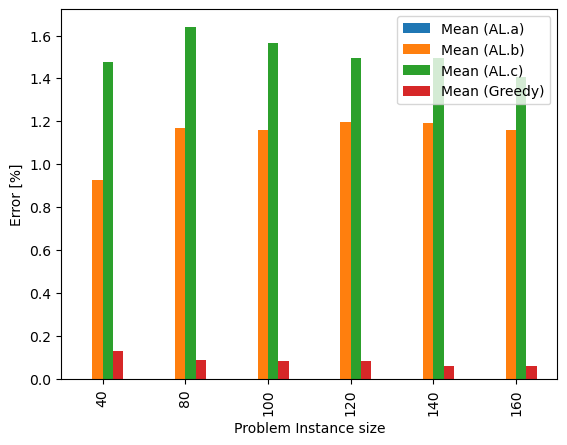

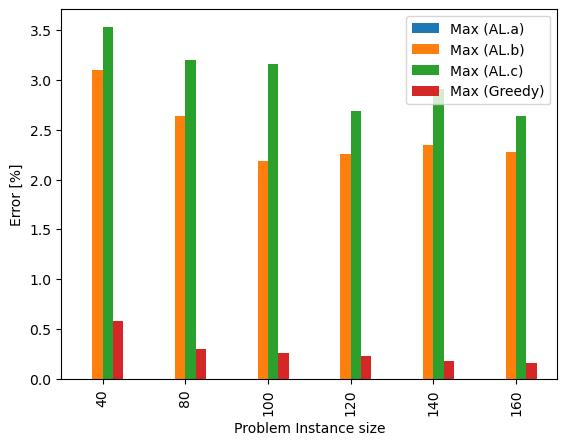

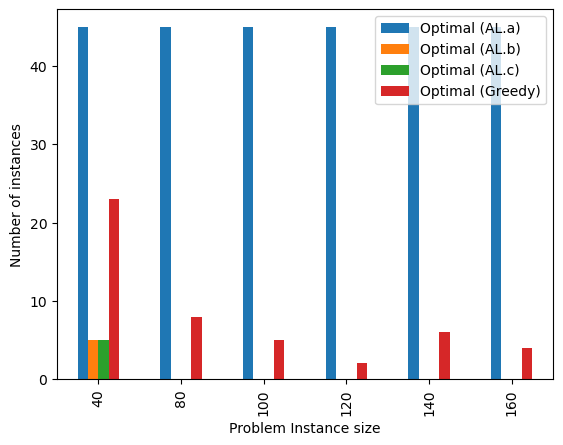

In [160]:
df_err = pd.DataFrame()
df_err['Mean (AL.a)'] = df_al.groupby(['n'])['err'].mean()
df_err['Mean (AL.b)'] = df_al_rk.groupby(['n'])['err'].mean()
df_err['Mean (AL.c)'] = df_al_dp.groupby(['n'])['err'].mean()
df_err['Mean (Greedy)'] = df_al.groupby(['n'])['err_greedy'].mean()
#df_err['Max (LR)'] = df_lr.groupby(['n'])['err'].max()
#df_err['Max (AL)'] = df_al.groupby(['n'])['err'].max()
#df_err['Max (Greedy)'] = df_al.groupby(['n'])['err_greedy'].max()

ax = df_err.plot.bar(xlabel='Problem Instance size', ylabel='Error [%]')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_mu_mean.png')

df_err = pd.DataFrame()
df_err['Max (AL.a)'] = df_al.groupby(['n'])['err'].max()
df_err['Max (AL.b)'] = df_al_rk.groupby(['n'])['err'].max()
df_err['Max (AL.c)'] = df_al_dp.groupby(['n'])['err'].max()
df_err['Max (Greedy)'] = df_al.groupby(['n'])['err_greedy'].max()
#df_err['Max (LR)'] = df_lr.groupby(['n'])['err'].max()
#df_err['Max (AL)'] = df_al.groupby(['n'])['err'].max()
#df_err['Max (Greedy)'] = df_al.groupby(['n'])['err_greedy'].max()

ax = df_err.plot.bar(xlabel='Problem Instance size', ylabel='Error [%]')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_mu_max.png')

df_optimal = pd.DataFrame()
mask_al_rk = df_al_rk['is_optimal']
mask_al_dp = df_al_dp['is_optimal']
mask_al = df_al['is_optimal']
mask_greedy = df_al['num_edges_optimal_sparsest'] == df_al['num_edges_greedy_sparsest']
df_optimal['Optimal (AL.a)'] = df_al[mask_al].groupby(['n'])['is_optimal'].count()
df_optimal['Optimal (AL.b)'] = df_al[mask_al_rk].groupby(['n'])['is_optimal'].count()
df_optimal['Optimal (AL.c)'] = df_al[mask_al_dp].groupby(['n'])['is_optimal'].count()
df_optimal['Optimal (Greedy)'] = df_al[mask_greedy].groupby(['n'])['is_optimal'].count()
#df_optimal['Sub optimal'] = df[~mask].groupby(['n'])['is_optimal'].count()

ax = df_optimal.plot.bar(xlabel='Problem Instance size', ylabel='Number of instances')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_mu_optimal.png')


df_err_greedy = pd.DataFrame()
df_err_greedy['err'] = df_al['err_greedy']
df_err_greedy['algo'] = 'd) Greedy'

df_al['algo'] = 'a) AL'
df_al_rk['algo'] = 'b) AL'
df_al_dp['algo'] = 'c) AL'

df_err = pd.concat([df_err_greedy, df_al[['algo', 'err']], df_al_rk[['algo', 'err']], df_al_dp[['algo', 'err']]])




<Figure size 640x480 with 0 Axes>

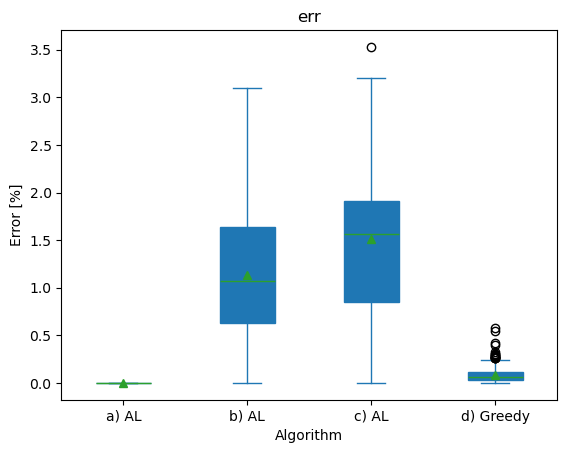

In [161]:


myFig = plt.figure()
ax = df_err.plot.box(column='err', by='algo', xlabel='Algorithm', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
#plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_mu_al.png')


<Figure size 640x480 with 0 Axes>

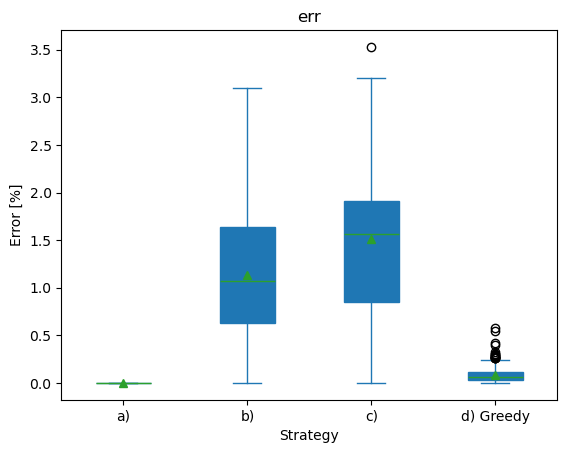

In [167]:
def ren(x):
    if x == 'd) Greedy':
        return 'd) Greedy'
    if x == 'a) AL':
        return 'a)'
    if x == 'b) AL':
        return 'b)'
    if x == 'c) AL':
        return 'c)'


df_err['penalty_type'] = df_err['algo'].apply(ren)

myFig = plt.figure()
ax = df_err.plot.box(column='err', by='penalty_type', xlabel='Strategy', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/quantum_day_2025/err_heuristic.png')


In [169]:
10**5/3600

27.77777777777778

In [171]:
10**3/3600

0.2777777777777778

In [168]:
df_err.groupby(['penalty_type']).count()

,err,algo
penalty_type,,
a),270,270
b),270,270
c),270,270
d) Greedy,270,270


In [489]:
root_dir = '/home/roman/gitlab/densest-subgraph'
# root_dir = '/home/omkar/Codes/Gitlab/New_directory/densest-subgraph/'

sizes = ['160']

logger.setLevel(logging.INFO)
#summary = compute_benchmark_instances(root_dir, AlgoLinear, sizes=sizes)
summary = compute_benchmark_instances_dp_penalties(root_dir, None, sizes=sizes)

0 40
time: 0.030849197995848954
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_40_1_dp_penalties.json ...
0 40
time: 0.02903042199613992
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_40_2_dp_penalties.json ...
0 40
time: 0.026193543992121704
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_40_3_dp_penalties.json ...
0 40
time: 0.02504259299894329
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_40_4_dp_penalties.json ...
0 40
time: 0.024247285997262225
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_40_5_dp_penalties.json ...
0 80
time: 0.023363340995274484
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/160/kcluster160_025_80_1_dp_penalties.json ...
0 80
time: 0.024203705004765652
Writing /h

In [490]:
n = [40, 80, 100, 120, 140, 160]
for i in n:
    folder = f'/home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/{i}'
    script_out = f'/home/roman/git-rudolfovo/biqbin-latest/parallel_biqbin_maxcut/run_dp_penalies_{i}.sh'
    cmd = 'OPENBLAS_NUM_THREADS=1 GOTO_NUM_THREADS=1 OMP_NUM_THREADS=1 mpiexec -n 8 python biqbin_qubo.py {} params'

    files = glob.glob(f'{folder}/*dp_penalties.json')
    with open(script_out, 'w') as f:
        for l in files:
            f.write(f'{cmd.format(l)}\n')

In [478]:
root_dir = '/home/roman/gitlab/densest-subgraph'
# root_dir = '/home/omkar/Codes/Gitlab/New_directory/densest-subgraph/'

sizes = ['160']

logger.setLevel(logging.INFO)
#summary = compute_benchmark_instances(root_dir, AlgoLinear, sizes=sizes)
summary = compute_benchmark_instances_rk_penalties(root_dir, None, sizes=sizes)

19.5 20
time: 0.02944930399826262
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_40_1_rk_penalties.json ...
19.5 20
time: 0.03136875400377903
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_40_2_rk_penalties.json ...
19.5 20
time: 0.028940775999217294
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_40_3_rk_penalties.json ...
19.5 20
time: 0.027394254007958807
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_40_4_rk_penalties.json ...
19.5 20
time: 0.024640522999106906
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_40_5_rk_penalties.json ...
39.5 40
time: 1.1197331509902142
Writing /home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/160/kcluster160_025_80_1_rk_penalties.json ...
39.5 40
time: 0.0282515449

In [479]:
n = [40, 80, 100, 120, 140, 160]
for i in n:
    folder = f'/home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/{i}'
    script_out = f'/home/roman/git-rudolfovo/biqbin-latest/parallel_biqbin_maxcut/run_rk_penalies_{i}.sh'
    cmd = 'OPENBLAS_NUM_THREADS=1 GOTO_NUM_THREADS=1 OMP_NUM_THREADS=1 mpiexec -n 8 python biqbin_qubo.py {} params'

    files = glob.glob(f'{folder}/*rk_penalties.json')
    with open(script_out, 'w') as f:
        for l in files:
            f.write(f'{cmd.format(l)}\n')

In [448]:
root_dir = '/home/roman/gitlab/densest-subgraph'
# root_dir = '/home/omkar/Codes/Gitlab/New_directory/densest-subgraph/'
result_folder = '/home/roman/gitlab/densest-subgraph/paper_experiments/sa_lr'

sizes=['40', '80', '100', '120', '140', '160']

logger.setLevel(logging.INFO)
summary = compute_benchmark_instances_sa(root_dir, AlgoLinear, sizes=sizes)

joblib.dump(summary, f'{result_folder}/AlgoLinear.pkl')

Computing size 40...
Computing instance kcluster40_025_10_1...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 29)
f(x)=-34.0
algorithm=AlgoLinear(g=(40, 597),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=5,lambda_max_iterations=50, lambda_step=0.1))
lambdai=5
greedy_used=False
number_of_iterations=1
best_computed_cardinality=10
G_greedy: 28, G_algo: 29
Computing instance kcluster40_025_10_2...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 30)
f(x)=-35.0
algorithm=AlgoLinear(g=(40, 562),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=5,lambda_max_iterations=50, lambda_step=0.1))
lambdai=5
greedy_used=False
number_of_iterations=1
best_computed_cardinality=10
G_greedy: 28, G_algo: 30
Computing instance kcluster40_025_10_3...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 27)
f(x)=-32.99999999999996
algorithm=A

INFO:root:algorithms.py, 638, AlgoLinear.compute(): Didn't find target cardinality=10, Going greedy with k=11


Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 39)
f(x)=-18.400000000000006
algorithm=AlgoLinear(g=(40, 372),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=2,lambda_max_iterations=50, lambda_step=0.1))
lambdai=2.5000000000000004
greedy_used=True
number_of_iterations=50
best_computed_cardinality=11
G_greedy: 38, G_algo: 39
Computing instance kcluster40_050_10_4...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 40)
f(x)=-24.000000000000007
algorithm=AlgoLinear(g=(40, 387),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=3,lambda_max_iterations=50, lambda_step=0.1))
lambdai=2.9
greedy_used=False
number_of_iterations=2
best_computed_cardinality=10
G_greedy: 36, G_algo: 40
Computing instance kcluster40_050_10_5...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 40)
f(x)=-15.0
algorithm=AlgoLinear(g=(40, 396),k=10, m

INFO:root:algorithms.py, 638, AlgoLinear.compute(): Didn't find target cardinality=10, Going greedy with k=11


Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 45)
f(x)=-3.3000000000000185
algorithm=AlgoLinear(g=(40, 203),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,lambda_max_iterations=50, lambda_step=0.1))
lambdai=-8.326672684688674e-17
greedy_used=True
number_of_iterations=50
best_computed_cardinality=11
G_greedy: 45, G_algo: 45
Computing instance kcluster40_075_10_2...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(10, 45)
f(x)=-1.0000000000000213
algorithm=AlgoLinear(g=(40, 196),k=10, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=0,lambda_max_iterations=50, lambda_step=0.1))
lambdai=0.1000000000000002
greedy_used=False
number_of_iterations=40
best_computed_cardinality=10
G_greedy: 45, G_algo: 45
Computing instance kcluster40_075_10_3...


...

INFO:root:algorithms.py, 638, AlgoLinear.compute(): Didn't find target cardinality=80, Going greedy with k=82


Result summary:
Is optimal: True, Is targdet cardinality: True
G=(80, 2592)
f(x)=-904.8000000000043
algorithm=AlgoLinear(g=(160, 3180),k=80, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=17,lambda_max_iterations=50, lambda_step=0.1))
lambdai=18.40000000000005
greedy_used=True
number_of_iterations=50
best_computed_cardinality=82
G_greedy: 2584, G_algo: 2592
Computing instance kcluster160_075_80_2...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(80, 2636)
f(x)=-916.0
algorithm=AlgoLinear(g=(160, 3180),k=80, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=18,lambda_max_iterations=50, lambda_step=0.1))
lambdai=18
greedy_used=False
number_of_iterations=1
best_computed_cardinality=80
G_greedy: 2630, G_algo: 2636
Computing instance kcluster160_075_80_3...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(80, 2607)
f(x)=-886.9999999999998
algorithm=AlgoLinear(

INFO:root:algorithms.py, 638, AlgoLinear.compute(): Didn't find target cardinality=80, Going greedy with k=83


Result summary:
Is optimal: False, Is targdet cardinality: True
G=(80, 2590)
f(x)=-953.0000000000003
algorithm=AlgoLinear(g=(160, 3180),k=80, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=18,lambda_max_iterations=50, lambda_step=0.1))
lambdai=18.60000000000006
greedy_used=True
number_of_iterations=50
best_computed_cardinality=83
G_greedy: 2582, G_algo: 2590
Computing instance kcluster160_075_120_1...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(120, 5588)
f(x)=-2275.999999999998
algorithm=AlgoLinear(g=(160, 3180),k=120, method=Sampler(sampler=SimulatedAnnealingSampler(), num_reads=10), result=Result, initial_lambda=32,lambda_max_iterations=50, lambda_step=0.1))
lambdai=31.9
greedy_used=False
number_of_iterations=2
best_computed_cardinality=120
G_greedy: 5584, G_algo: 5588
Computing instance kcluster160_075_120_2...
Result summary:
Is optimal: True, Is targdet cardinality: True
G=(120, 5601)
f(x)=-2421.0000000000005

['/home/roman/gitlab/densest-subgraph/paper_experiments/sa_lr/AlgoLinear.pkl']

In [112]:
result_folder = '/home/roman/gitlab/densest-subgraph/paper_experiments/sa_lr'
summary = joblib.load(f'{result_folder}/AlgoLinear.pkl')
df = pd.DataFrame(get_result_data_sa(summary))
df['err'] = 100*(df['num_edges_sparsest'] - df['num_edges_optimal_sparsest'])/df['num_edges_optimal_sparsest']
df['err_greedy'] = 100*(df['num_edges_greedy_sparsest'] - df['num_edges_optimal_sparsest'])/df['num_edges_optimal_sparsest']
df['err'].max()

df['algo'] = 'SA LR'

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['size'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]

df_lr = df.copy()


In [113]:
result_folder = '/home/roman/gitlab/densest-subgraph/paper_experiments/sa_al'
summary = joblib.load(f'{result_folder}/AlgoAL.pkl')
df = pd.DataFrame(get_result_data_sa(summary))
df['err'] = 100*(df['num_edges_sparsest'] - df['num_edges_optimal_sparsest'])/df['num_edges_optimal_sparsest']
df['err_greedy'] = 100*(df['num_edges_greedy_sparsest'] - df['num_edges_optimal_sparsest'])/df['num_edges_optimal_sparsest']
df['err'].max()

df['algo'] = 'SA AL'

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['size'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]

df_al = df.copy()

df_lr_al = pd.concat([df_lr, df_al]).reset_index(drop=True)

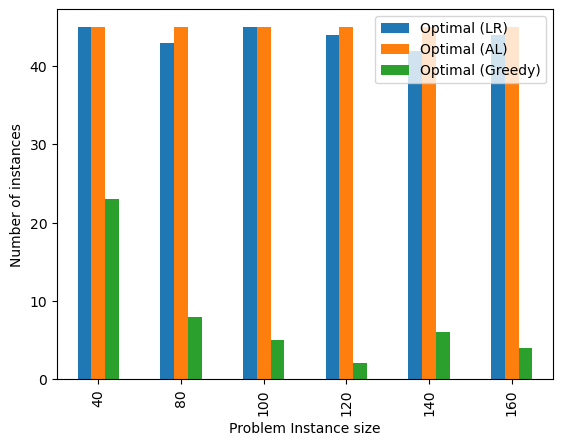

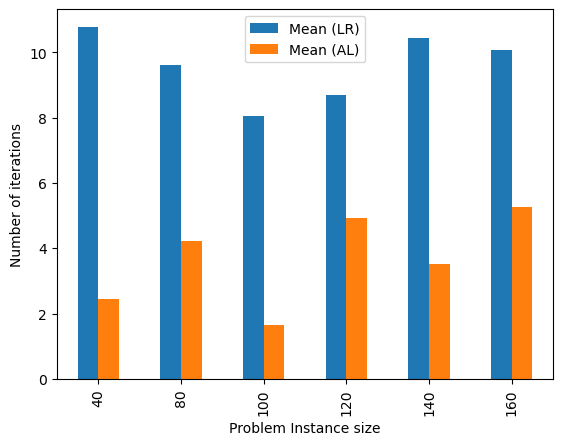

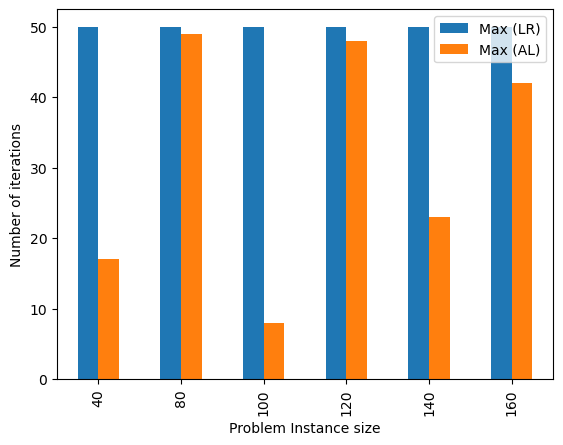

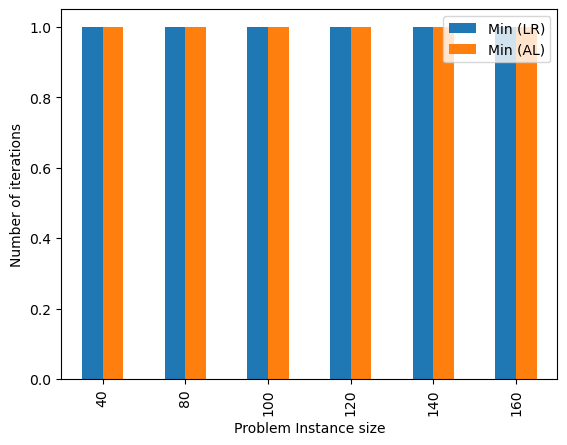

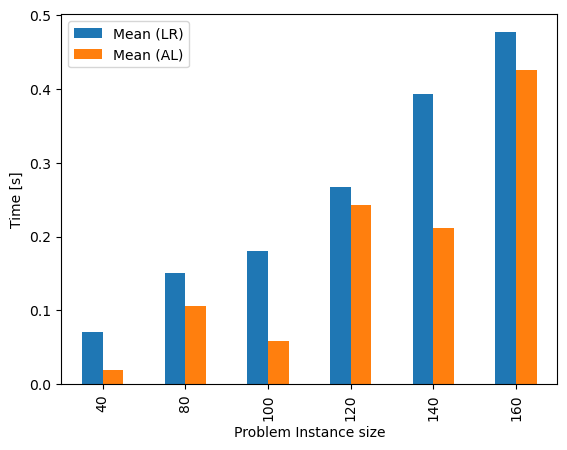

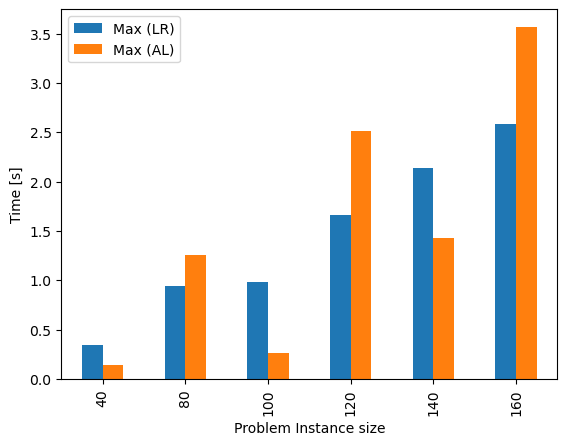

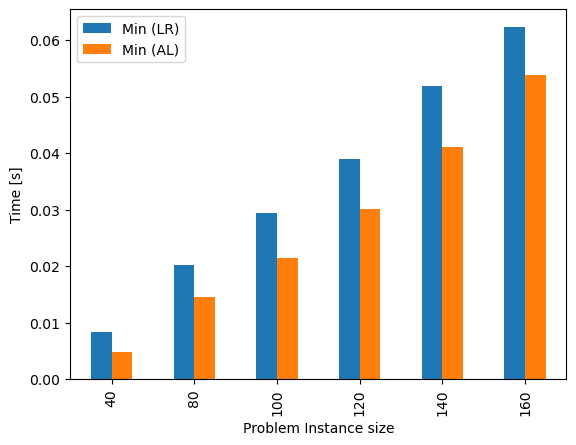

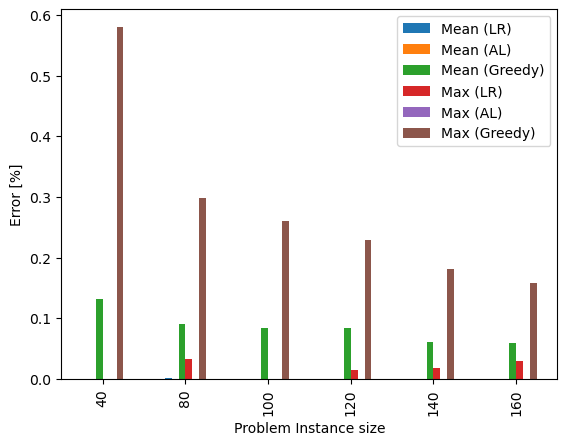

In [114]:
df_optimal = pd.DataFrame()
mask_lr = df_lr['is_optimal']
mask_al = df_al['is_optimal']
mask_greedy = df_lr['num_edges_optimal_sparsest'] == df_lr['num_edges_greedy_sparsest']
df_optimal['Optimal (LR)'] = df_lr[mask_lr].groupby(['n'])['is_optimal'].count()
df_optimal['Optimal (AL)'] = df_al[mask_al].groupby(['n'])['is_optimal'].count()
df_optimal['Optimal (Greedy)'] = df_lr[mask_greedy].groupby(['n'])['is_optimal'].count()
#df_optimal['Sub optimal'] = df[~mask].groupby(['n'])['is_optimal'].count()

ax = df_optimal.plot.bar(xlabel='Problem Instance size', ylabel='Number of instances')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/optimal.png')


df_iter = pd.DataFrame()
df_iter['Mean (LR)'] = df_lr.groupby(['n'])['lambda_number_of_iterations'].mean()
df_iter['Mean (AL)'] = df_al.groupby(['n'])['number_of_iterations'].mean()

ax = df_iter.plot.bar(xlabel='Problem Instance size', ylabel='Number of iterations')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/iter_mean.png')

df_iter = pd.DataFrame()
df_iter['Max (LR)'] = df_lr.groupby(['n'])['lambda_number_of_iterations'].max()
df_iter['Max (AL)'] = df_al.groupby(['n'])['number_of_iterations'].max()

ax = df_iter.plot.bar(xlabel='Problem Instance size', ylabel='Number of iterations')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/iter_max.png')

df_iter = pd.DataFrame()
df_iter['Min (LR)'] = df_lr.groupby(['n'])['lambda_number_of_iterations'].min()
df_iter['Min (AL)'] = df_al.groupby(['n'])['number_of_iterations'].min()

df_iter.plot.bar(xlabel='Problem Instance size', ylabel='Number of iterations')

df_time = pd.DataFrame()
df_time['Mean (LR)'] = df_lr.groupby(['n'])['time'].mean()
df_time['Mean (AL)'] = df_al.groupby(['n'])['time'].mean()

ax = df_time.plot.bar(xlabel='Problem Instance size', ylabel='Time [s]')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_mean.png')

df_time = pd.DataFrame()
df_time['Max (LR)'] = df_lr.groupby(['n'])['time'].max()
df_time['Max (AL)'] = df_al.groupby(['n'])['time'].max()

ax = df_time.plot.bar(xlabel='Problem Instance size', ylabel='Time [s]')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_max.png')

df_time = pd.DataFrame()
df_time['Min (LR)'] = df_lr.groupby(['n'])['time'].min()
df_time['Min (AL)'] = df_al.groupby(['n'])['time'].min()

df_time.plot.bar(xlabel='Problem Instance size', ylabel='Time [s]')

df_err = pd.DataFrame()
df_err['Mean (LR)'] = df_lr.groupby(['n'])['err'].mean()
df_err['Mean (AL)'] = df_al.groupby(['n'])['err'].mean()
df_err['Mean (Greedy)'] = df_al.groupby(['n'])['err_greedy'].mean()
df_err['Max (LR)'] = df_lr.groupby(['n'])['err'].max()
df_err['Max (AL)'] = df_al.groupby(['n'])['err'].max()
df_err['Max (Greedy)'] = df_al.groupby(['n'])['err_greedy'].max()

ax = df_err.plot.bar(xlabel='Problem Instance size', ylabel='Error [%]')
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err.png')

In [115]:
df_lr.columns

Index(['algorithm', 'g', 'method_sampler', 'qubo', 'computed_cardinality',
       'mui', 'best_computed_cardinality', 'best_computed_cardinality_x',
       'initial_lambda', 'lambdai', 'lambda_max_iterations',
       'lambda_number_of_iterations', 'lambda_step', 'greedy_used',
       'is_optimal', 'target_cardinality_reached', 'num_edges_sparsest',
       'num_edges_greedy_sparsest', 'num_edges_optimal_sparsest', 'instance',
       'n', 'time', 'details_g', 'details_sampler_response_x',
       'details_sampler_response_value',
       'details_sampler_response_cardinality',
       'details_sampler_response_sampler_response',
       'details_additional_info_algo_summary_algorithm',
       'details_additional_info_algo_summary_g',
       'details_additional_info_algo_summary_method_sampler',
       'details_additional_info_algo_summary_qubo',
       'details_additional_info_algo_summary_computed_cardinality',
       'details_additional_info_algo_summary_mui',
       'details_additional_in

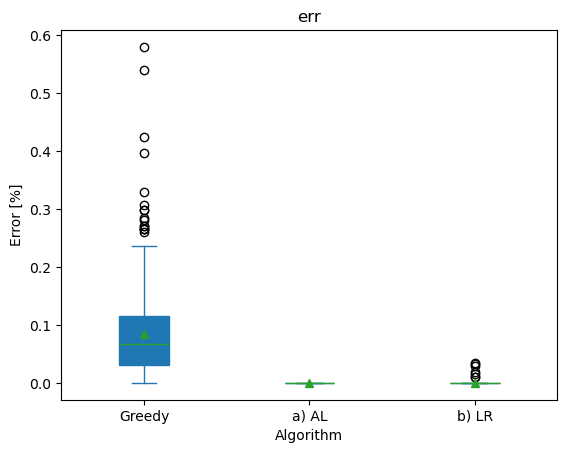

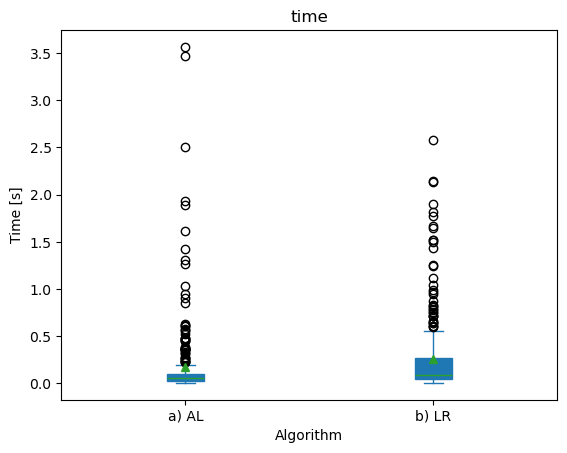

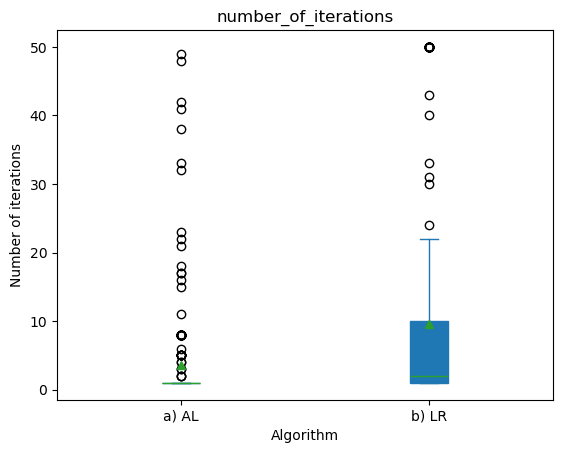

In [116]:
df_err_greedy = pd.DataFrame()
df_err_greedy['err'] = df_al['err_greedy']
df_err_greedy['n'] = df_al['n']
df_err_greedy['instance'] = df_al['instance']
df_err_greedy['density'] = df_al['density']
df_err_greedy['algo'] = 'Greedy'
df_err_greedy['is_optimal'] = df_al['num_edges_optimal_sparsest'] == df_al['num_edges_greedy_sparsest']

df_greedy = df_err_greedy.copy()

df_lr['algo'] = 'b) LR'
df_al['algo'] = 'a) AL'
df_lr['number_of_iterations'] = df_lr['lambda_number_of_iterations']

df_err = pd.concat([df_err_greedy, df_lr[['algo', 'err']], df_al[['algo', 'err']]]).reset_index()

ax = df_err.plot.box(column='err', by='algo', xlabel='Algorithm', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_heuristics.png')

df_time = pd.concat([df_lr[['algo', 'time']], df_al[['algo', 'time']]]).reset_index()

ax = df_time.plot.box(column='time', by='algo', xlabel='Algorithm', ylabel='Time [s]', logy=False, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_heuristics.png')

df_iterations = pd.concat([df_lr[['algo', 'number_of_iterations']], df_al[['algo', 'number_of_iterations']]]).reset_index()

ax = df_iterations.plot.box(column='number_of_iterations', by='algo', xlabel='Algorithm', ylabel='Number of iterations', logy=False, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/iterations_heuristics.png')




In [117]:
df_err.groupby(['algo'])[['err']].count()

,err
algo,
Greedy,270
a) AL,270
b) LR,270


In [118]:
df_err

,index,err,n,instance,density,algo,is_optimal
0,0,0.133156,40.0,kcluster40_025_10_1,75.0,Greedy,False
1,1,0.266667,40.0,kcluster40_025_10_2,75.0,Greedy,False
2,2,0.265604,40.0,kcluster40_025_10_3,75.0,Greedy,False
3,3,0.265604,40.0,kcluster40_025_10_4,75.0,Greedy,False
4,4,0.397878,40.0,kcluster40_025_10_5,75.0,Greedy,False
...,...,...,...,...,...,...,...
805,265,0.000000,NaN,NaN,NaN,a) AL,NaN
806,266,0.000000,NaN,NaN,NaN,a) AL,NaN
807,267,0.000000,NaN,NaN,NaN,a) AL,NaN
808,268,0.000000,NaN,NaN,NaN,a) AL,NaN


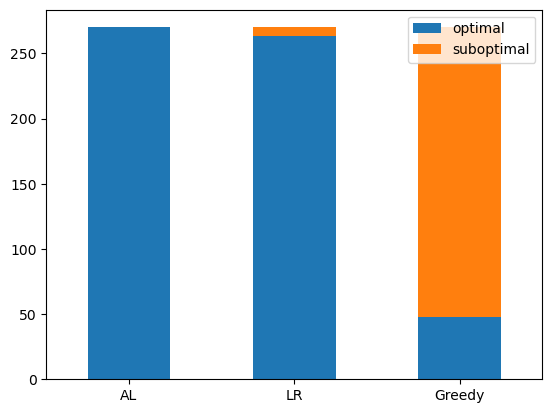

In [119]:
mask_lr = df_lr['is_optimal'] == True
mask_al = df_al['is_optimal'] == True
mask_greedy = df_err_greedy['is_optimal'] == True
optimal_lr = df_lr[mask_lr]['is_optimal'] .count()
optimal_al = df_al[mask_al]['is_optimal'] .count()
optimal_greedy = df_err_greedy[mask_greedy]['is_optimal'] .count()
sub_optimal_lr = df_lr[~mask_lr]['is_optimal'] .count()
sub_optimal_al = df_al[~mask_al]['is_optimal'] .count()
sub_optimal_greedy = df_err_greedy[~mask_greedy]['is_optimal'] .count()

index = ['AL', 'LR', 'Greedy']
optimal = [optimal_al, optimal_lr, optimal_greedy]
suboptimal = [sub_optimal_al, sub_optimal_lr, sub_optimal_greedy]
df_optimal = pd.DataFrame({
    'optimal': optimal, 'suboptimal': suboptimal 
}, index=index)

ax = df_optimal.plot.bar(stacked=True, rot=0)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/optimal_vs_suboptimal_heuristics.png')


In [120]:
optimal_greedy

np.int64(48)

In [121]:
df_al.groupby(['n'])['err'].max()

n
40     0.0
80     0.0
100    0.0
120    0.0
140    0.0
160    0.0
Name: err, dtype: float64

In [122]:
import glob

n = [40, 80, 100, 120, 140, 160]
for i in n:
    folder = f'/home/roman/gitlab/densest-subgraph/paper_experiments/exact/{i}'
    script_out = f'/home/roman/git-rudolfovo/biqbin-latest/parallel_biqbin_maxcut/run_mu_0_{i}.sh'
    cmd = 'OPENBLAS_NUM_THREADS=1 GOTO_NUM_THREADS=1 OMP_NUM_THREADS=1 mpiexec -n 8 python biqbin_qubo.py {} params'

    files = glob.glob(f'{folder}/*mu_0.json')
    with open(script_out, 'w') as f:
        for l in files:
            f.write(f'{cmd.format(l)}\n')

    


In [123]:
#ns = [40, 80, 100, 120, 140, 160]
ns = [40]
results_folder_rk = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact_rk_penalties/{}/*_rk_penalties.json'
results_folder_dp = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact_dp_penalties/{}/*_dp_penalties.json'

df_rk = pd.concat([pd.DataFrame(get_result_data(results_folder_rk.format(i))) for i in ns])
df_dp = pd.concat([pd.DataFrame(get_result_data(results_folder_dp.format(i))) for i in ns])

import re

s = df_rk['input_instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df_rk['size'] = s[:, 0]
df_rk['density'] = 100-s[:, 1]
df_rk['k'] = s[:, 2]
df_rk['is_target_cardinality'] = df_rk['k']==df_rk['result_qubo_cardinality']

assert df_rk['is_target_cardinality'].sum() == len(df_rk) 

s = df_dp['input_instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df_dp['size'] = s[:, 0]
df_dp['density'] = 100-s[:, 1]
df_dp['k'] = s[:, 2]
df_dp['is_target_cardinality'] = df_dp['k']==df_dp['result_qubo_cardinality']

assert df_dp['is_target_cardinality'].sum() == len(df_dp) 

results_folder_mu_0 = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact/{}/*_mu_0.json'
results_folder_mu_nz = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact/{}/*_mu_nz.json'

df_mu_0 = pd.concat([pd.DataFrame(get_result_data(results_folder_mu_0.format(i))) for i in ns])
df_mu_nz = pd.concat([pd.DataFrame(get_result_data(results_folder_mu_nz.format(i))) for i in ns])

df = pd.concat([df_mu_0, df_mu_nz])
df['result_time'] = df['result_time']+df['input_preprocessing_time']

s = df['input_instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['size'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

assert df['is_target_cardinality'].sum() == len(df) 

In [124]:
df_rk.columns

Index(['result_time', 'result_maxcut_computed_val', 'result_maxcut_solution',
       'result_maxcut_x', 'result_qubo_computed_val', 'result_qubo_solution',
       'result_qubo_x', 'result_qubo_cardinality', 'input_instance',
       'input_lambda', 'input_mu', 'input_optimum', 'input_target_cardinality',
       'input_qubo_shape', 'input_qubo_nnz', 'input_qubo_row',
       'input_qubo_col', 'input_qubo_data', 'size', 'density', 'k',
       'is_target_cardinality'],
      dtype='object')

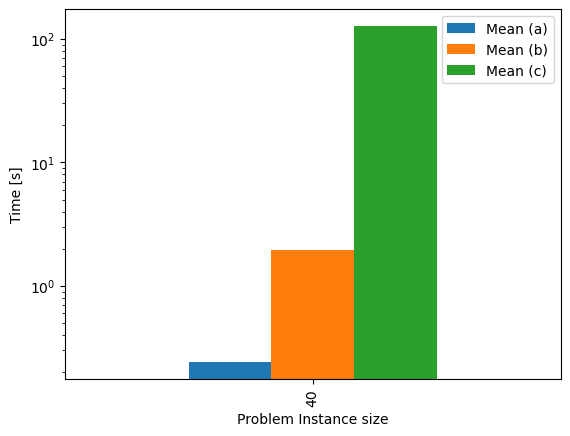

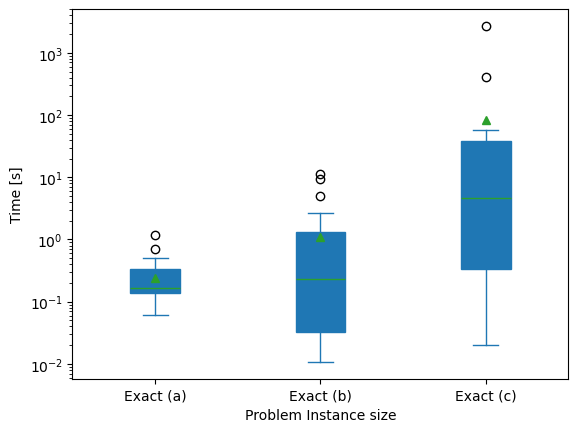

In [125]:
df_times = pd.DataFrame()
df_times['Mean (a)'] = df.groupby(['size'])['result_time'].mean()
df_times['Mean (b)'] = df_rk.groupby(['size'])['result_time'].mean()
df_times['Mean (c)'] = df_dp.groupby(['size'])['result_time'].mean()
#df_times['Max'] = df.groupby(['size'])['time'].max()
#df_times['Min'] = df.groupby(['size'])['time'].min()

#df_times['Mean (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].mean()
#df_times['Max (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].max()
#df_times['Min (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].min()

ax = df_times.plot.bar(xlabel='Problem Instance size', ylabel='Time [s]', logy=True)

df_times = pd.DataFrame()
df_times['Exact (a)'] = df['result_time']   #df.groupby(['size'])['result_time'].max()
df_times['Exact (b)'] = df_rk['result_time']   #df.groupby(['size'])['result_time'].max()
df_times['Exact (c)'] = df_dp['result_time']   #df.groupby(['size'])['result_time'].max()
ax = df_times.plot.box(xlabel='Problem Instance size', ylabel='Time [s]', logy=True, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_exact_mu_40.png')

#df_times['Max (a)'] = df[['size', 'result_time']]   #df.groupby(['size'])['result_time'].max()
#df_times['Max (b)'] = df_rk.groupby(['size'])['result_time'].max()
#df_times['Max (c)'] = df_dp.groupby(['size'])['result_time'].max()
#df_times['Max'] = df.groupby(['size'])['time'].max()
#df_times['Min'] = df.groupby(['size'])['time'].min()

#df_times['Mean (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].mean()
#df_times['Max (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].max()
#df_times['Min (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].min()

#ax = df_times.plot.box(xlabel='Problem Instance size', ylabel='Time [s]', logy=True)

In [126]:
df.groupby(['size'])['result_time'].setindex('size')

AttributeError: 'SeriesGroupBy' object has no attribute 'setindex'

In [127]:
ns = [40, 80, 100, 120, 140, 160]
#ns = [40]
results_folder_mu_0 = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact/{}/*_mu_0.json'
results_folder_mu_nz = '/home/roman/gitlab/densest-subgraph/paper_experiments/exact/{}/*_mu_nz.json'

df_mu_0 = pd.concat([pd.DataFrame(get_result_data(results_folder_mu_0.format(i))) for i in ns])
df_mu_nz = pd.concat([pd.DataFrame(get_result_data(results_folder_mu_nz.format(i))) for i in ns])

df = pd.concat([df_mu_0, df_mu_nz])


In [128]:
df['time'] = df['result_time']+df['input_preprocessing_time']

In [129]:
import re

s = df['input_instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['size'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

assert df['is_target_cardinality'].sum() == len(df) 

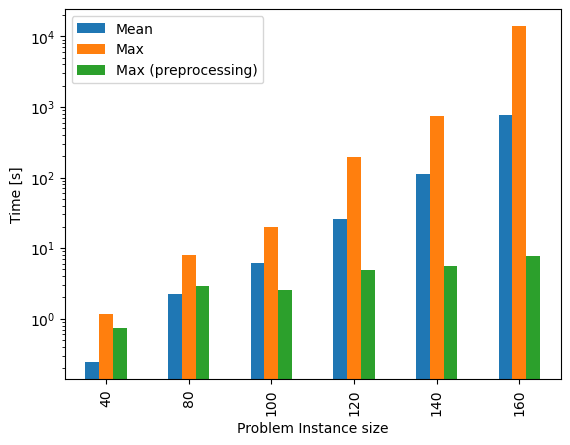

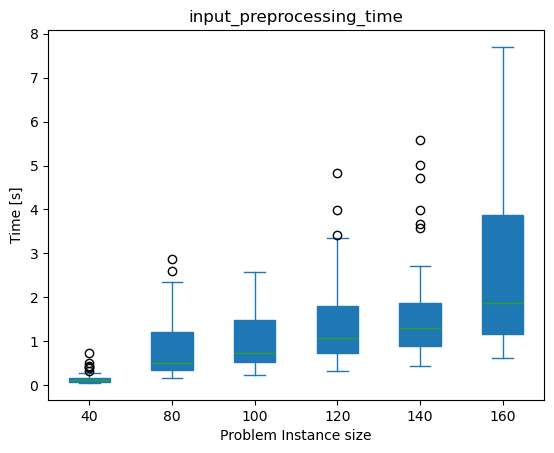

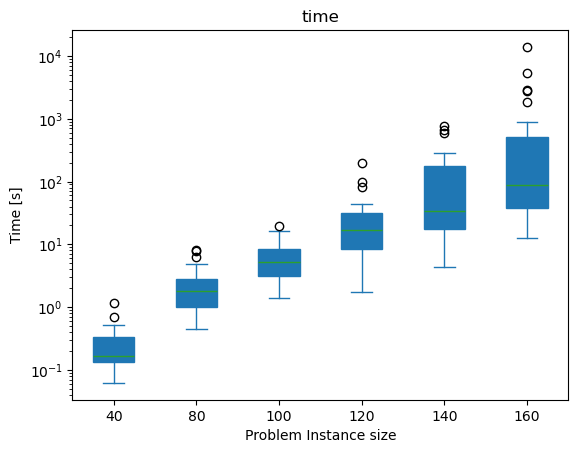

In [130]:
df_times = pd.DataFrame()
df_times['Mean'] = df.groupby(['size'])['time'].mean()
df_times['Max'] = df.groupby(['size'])['time'].max()
#df_times['Min'] = df.groupby(['size'])['time'].min()

#df_times['Mean (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].mean()
df_times['Max (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].max()
#df_times['Min (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].min()

ax = df_times.plot.bar(xlabel='Problem Instance size', ylabel='Time [s]', logy=True)
#ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/exact.png')


ax = df.reset_index().plot.box(column='input_preprocessing_time', by='size', xlabel='Problem Instance size', ylabel='Time [s]', logy=False, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_exact_preprocessing.png')
ax = df.reset_index().plot.box(column='time', by='size', xlabel='Problem Instance size', ylabel='Time [s]', logy=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_exact.png')


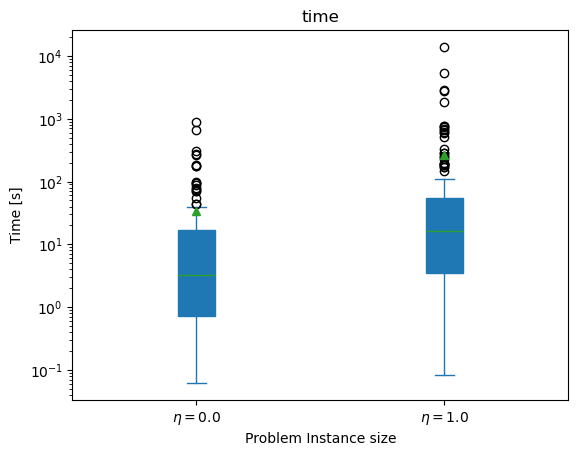

In [131]:
df_P = df.copy().reset_index()

df_P['mu'] = df_P['input_mu'].apply(lambda x: f'$\eta=${x}')

ax = df_P.plot.box(column='time', by='mu', xlabel='Problem Instance size', ylabel='Time [s]', logy=True, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/time_exact_mu_0_1.png')



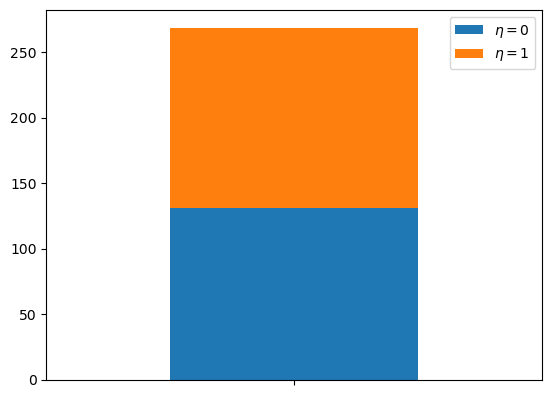

In [132]:
mask = df_P['input_mu'] == 0
mu0 = df_P[mask]['input_mu'] .count()
mu1 = df_P[~mask]['input_mu'] .count()

index = ['']
mu = [mu0, mu1]
df_mu = pd.DataFrame({
    '$\eta=0$': [mu0], '$\eta=1$': [mu1] 
}, index=index)

ax = df_mu.plot.bar(stacked=True, rot=0)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/mu0_vs_mu1_exact.png')


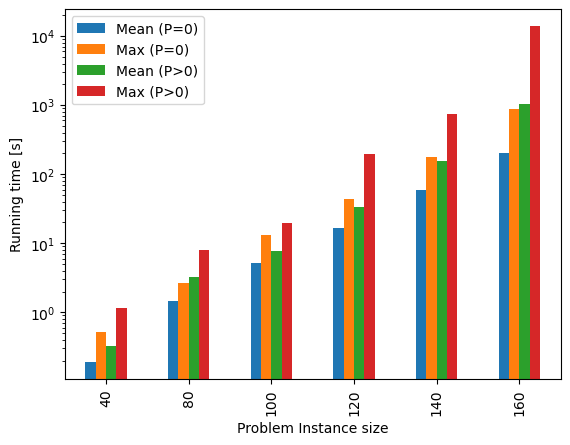

In [133]:
mask = df['density'] == 75
mask = df['input_mu'] == 0

df_times = pd.DataFrame()
df_times['Mean (P=0)'] = df[mask].groupby(['size'])['time'].mean()
df_times['Max (P=0)'] = df[mask].groupby(['size'])['time'].max()
df_times['Mean (P>0)'] = df[~mask].groupby(['size'])['time'].mean()
df_times['Max (P>0)'] = df[~mask].groupby(['size'])['time'].max()
#df_times['Min'] = df[mask].groupby(['size'])['time'].min()
#df_times['Max (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].max()

ax = df_times.plot.bar(xlabel='Problem Instance size', ylabel='Running time [s]', logy=True)
ax.figure.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/exact_P.png')

<Axes: xlabel='Problem Instance size', ylabel='Running time [s]'>

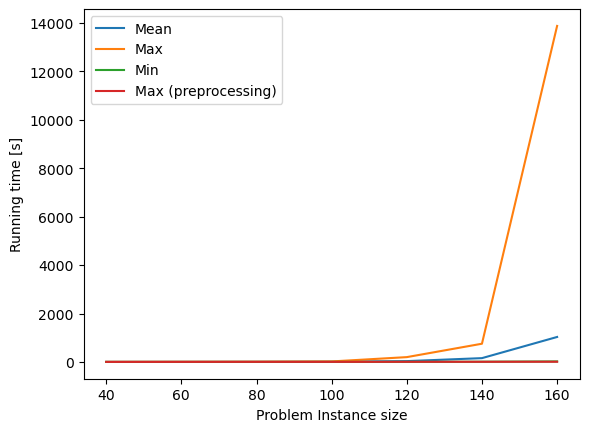

In [134]:
mask = df['input_mu'] != 0
df_times = pd.DataFrame()
df_times['Mean'] = df[mask].groupby(['size'])['time'].mean()
df_times['Max'] = df[mask].groupby(['size'])['time'].max()
df_times['Min'] = df[mask].groupby(['size'])['time'].min()
df_times['Max (preprocessing)'] = df.groupby(['size'])['input_preprocessing_time'].max()

df_times.plot(xlabel='Problem Instance size', ylabel='Running time [s]')

In [135]:
df['input_mu'].max()

1.0

In [136]:
class AlgoMaxIndependentSet(MaxIndependentSet):
    def __init__(self, g):
        super().__init__(
            g,
            method=Sampler(neal.SimulatedAnnealingSampler(), num_reads=10),
            result=Result,
            lambda_max_iterations=10
        )


In [137]:
def mis_compute_benchmark_instances(files, get_algorithm):
    summary = []
    for instance in files:

        optimum = None
        with open(instance) as f:
            qubo =  from_sparse(json.load(f)['qubo'])

        try:
            result = instance.split('/')[-1]

            file = f'{instance.replace(result, 'results/')}{result}.output.json'
            
            with open(file) as f:
                optimum = json.load(f)['qubo']['cardinality']
        except:
            pass
            

        A = (qubo.T+qubo)/2
        np.fill_diagonal(A, 0)
            

        #if instance != 'kcluster160_025_40_2': continue
        
        g = nx.from_numpy_array(A)
        
#        some_node_labeling_example = {label: f'example_{label}:' for label in g.nodes}
#        g = nx.relabel_nodes(g, some_node_labeling_example, copy=True)
        
        
        print(f'\nSolving instance={instance} ...')
    
        start = timer()
        #nx_ind_set = nx.algorithms.approximation.maximum_independent_set(g)
        time_nx = timer()-start
        #g_nx = nx.induced_subgraph(g,nx_ind_set)

        algorithm = get_algorithm(g=g)

        start = timer()

        try:
            result = algorithm.compute()
        except DidNotConverge as err:
            print(err)
            print(colored('Skipping.', 'red'))
            continue

        end = timer()
        time = float(end-start)
        print(f'Time: {time}, nx Time: {time_nx}')
            
        summary.append((algorithm.summary(), result.summary()))

        if optimum is None: 
            print('Optimum ... unknown.')
            print_color = 'yellow' 
        else:
            print(f'Optimum={optimum}')
            if optimum == result['g'].number_of_nodes():
                print_color = 'green' 
            else:
                print_color = 'red' 
        
        print('Result summary:')
        print(colored(f'{result}', print_color))
        print()
#        print(f'G_networkx: ({g_nx.number_of_nodes()}, {g_nx.number_of_edges()}), G_algo: ({result['g'].number_of_nodes()}, {result['g'].number_of_edges()})')
        print(f'G_algo: ({result['g'].number_of_nodes()}, {result['g'].number_of_edges()})')

        #break

    return summary

In [138]:
def get_result_data_omkar(results):
    for instance in results.keys():
        yield {**{'instance': instance}, **dict(flatten_dict(result[instance]))}

folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results/{}/DwaveAlgoLinearToken'

n = [40, 80, 100, 120, 140, 160]

r = []
for i in n:
    file = folder.format(i)

    try:
        result = joblib.load(file)
        r.append(pd.DataFrame(get_result_data_omkar(result)))
    except:
        pass

df = pd.concat(r)
df = df[df['successful'] == True]


import re

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['n'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
#df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

df['optimum'] = df['n']*(df['n']-1)/2 - df['optimum']
df['edges_algo'] = df['n']*(df['n']-1)/2 - df['edges_algo']

df['err'] = 100*(df['edges_algo'] - df['optimum'])/df['optimum']

df['algo'] = 'QA LR'
df_lr_qa = df.copy()



In [139]:
df_lr_qa_T1 = df.copy()

In [140]:

def f(x):
    e = x[0]['embedding']
    a = np.concatenate([e[i] for i in e.keys()])
    return len(set(a))
    
df['nodes_embedding'] = df['summary_additional_info_algo_summary_method_embedding_list'].apply(lambda x: f(x)) 


<Figure size 640x480 with 0 Axes>

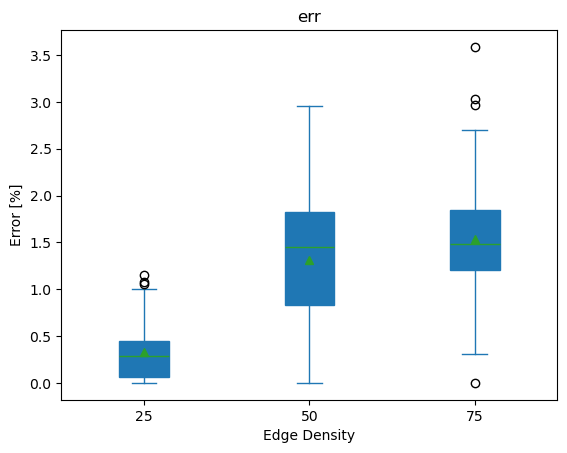

In [141]:

myFig = plt.figure()
ax = df.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)

<Figure size 640x480 with 0 Axes>

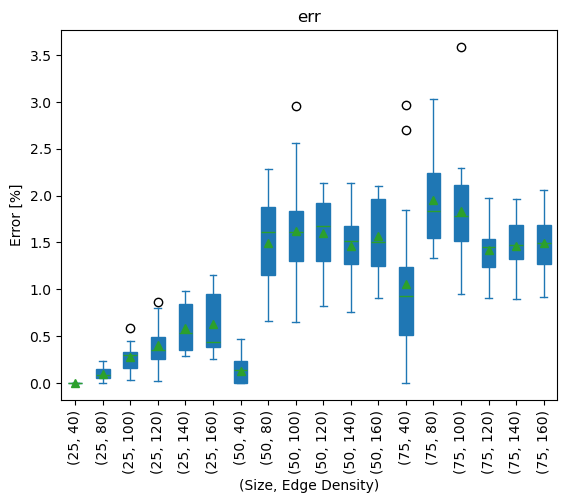

In [142]:
myFig = plt.figure()
ax = df.reset_index().plot.box(column='err', by=['density', 'n'], xlabel='(Size, Edge Density)', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)

In [143]:
folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results/{}/DwaveAlgoAugementedLagrangianToken'

n = [40, 80] #, 100, 120, 140, 160]

r = []
for i in n:
    file = folder.format(i)

    try:
        result = joblib.load(file)
        r.append(pd.DataFrame(get_result_data_omkar(result)))
    except:
        pass

df = pd.concat(r).reset_index(drop=True)
df_al_qa = df.copy()

folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results/{}/DwaveAlgoAugementedLagrangianToken_no_clique_emb'


n = [100, 120, 140, 160]

r = []
for i in n:
    file = folder.format(i)

    try:
        result = joblib.load(file)
        r.append(pd.DataFrame(get_result_data_omkar(result)))
    except:
        pass

df = pd.concat(r).reset_index(drop=True)

df_al_qa_no_clique = df.copy()

df_al_qa = pd.concat([df_al_qa, df_al_qa_no_clique]).reset_index(drop=True)
df_al_qa['algo'] = 'QA AL'

df_al_qa['topology'] = 'Pegasus'

import re

df = df_al_qa

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['n'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
#df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

df['optimum'] = df['n']*(df['n']-1)/2 - df['optimum']
df['edges_algo'] = df['n']*(df['n']-1)/2 - df['edges_algo']

df['err'] = 100*(df['edges_algo'] - df['optimum'])/df['optimum']

#df = df[df['successful'] == True].reset_index(drop=True)

df_al_qa_T1 = df_al_qa[df_al_qa['successful']==True].copy().reset_index(drop=True)


In [144]:
df_al_qa.groupby(['successful', 'n'])['instance'].count()

successful  n  
False       80     14
            100     3
            120     2
            140     2
True        40     45
            80     31
            100    42
            120    43
            140    43
Name: instance, dtype: int64

In [145]:
df_al_qa_T1.groupby('n').count()

,instance,successful,optimum,target_cardinality_reached,edges_greedy,edges_algo,summary_g,summary_sampler_response_x,summary_sampler_response_value,summary_sampler_response_cardinality,...,algo_summary_initial_lambda,algo_summary_lambdai,algo_summary_step,algo_summary_max_iterations,algo_summary_number_of_iterations,algo,topology,density,k,err
n,,,,,,,,,,,,,,,,,,,,,
40,45,45,45,45,45,45,45,45,45,45,...,0,0,0,0,0,45,45,45,45,45
80,31,31,31,31,31,31,31,31,31,31,...,0,0,0,0,0,31,31,31,31,31
100,42,42,42,42,42,42,42,42,42,42,...,0,0,0,0,0,42,42,42,42,42
120,43,43,43,43,43,43,43,43,43,43,...,0,0,0,0,0,43,43,43,43,43
140,43,43,43,43,43,43,43,43,43,43,...,0,0,0,0,0,43,43,43,43,43


<Figure size 640x480 with 0 Axes>

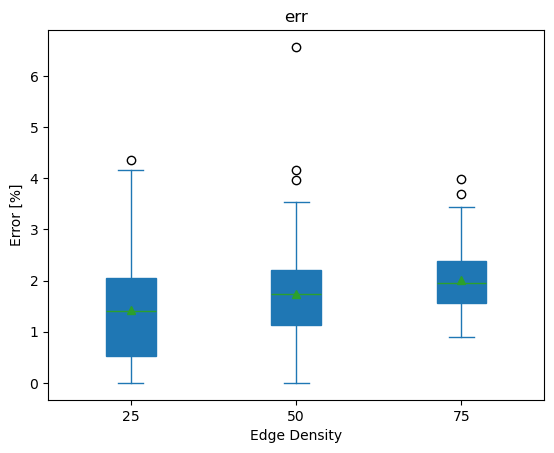

In [146]:
myFig = plt.figure()
ax = df_al_qa_T1.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)


In [148]:
dff = pd.concat([df_lr_qa, df_greedy, df_al_qa_T1, df_lr_al]).reset_index(drop=True)
#dff = dff[dff['instance'].isin(df_al_qa['instance'])].reset_index()

dff.groupby(['algo'])[['instance']].count()

,instance
algo,
Greedy,270
QA AL,204
QA LR,268
SA AL,270
SA LR,270


In [149]:
df_greedy['density']

0      75
1      75
2      75
3      75
4      75
       ..
265    25
266    25
267    25
268    25
269    25
Name: density, Length: 270, dtype: int64

In [150]:
def ren(x):
    if x == 'Greedy':
        return 'c) Greedy'
    if x == 'QA AL':
        return 'b)'
    if x == 'QA LR':
        return 'a)'


dff['penalty_type'] = dff['algo'].apply(ren)

<Figure size 640x480 with 0 Axes>

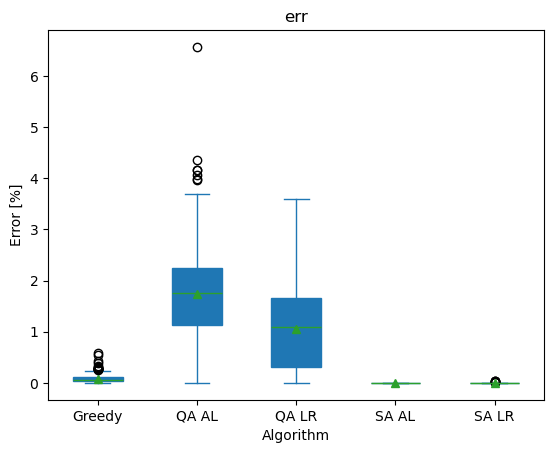

In [151]:
myFig = plt.figure()
ax = dff.plot.box(column='err', by=['algo'], xlabel='Algorithm', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
#plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_QA.png')

In [152]:

dff.groupby(['algo'])[['instance']].count()

,instance
algo,
Greedy,270
QA AL,204
QA LR,268
SA AL,270
SA LR,270


<Figure size 640x480 with 0 Axes>

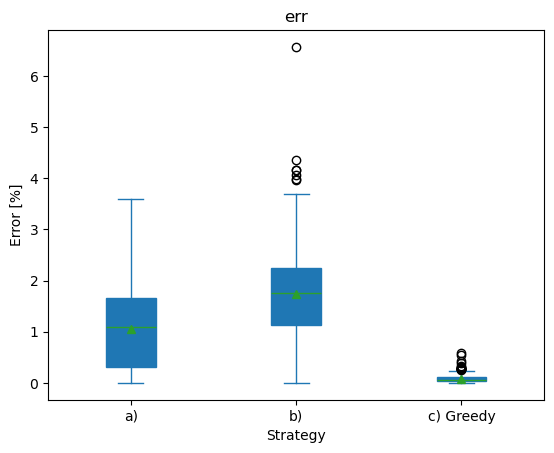

In [156]:
myFig = plt.figure()
ax = dff.plot.box(column='err', by=['penalty_type'], xlabel='Strategy', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
plt.savefig('/home/roman/quantum_day_2025/err_QA.png')

In [111]:
dff.groupby(['penalty_type'])[['instance']].count()

,instance
penalty_type,
a),445
b),204
c) Greedy,225


In [90]:
dff

,index,instance,successful,optimum,target_cardinality_reached,edges_greedy,edges_algo,summary_g,summary_sampler_response_x,summary_sampler_response_value,...,details_additional_info_g_for_greedy,err_greedy,size,step,max_iterations,number_of_iterations,details_additional_info_algo_summary_step,details_additional_info_algo_summary_max_iterations,details_additional_info_algo_summary_number_of_iterations,penalty_type
0,0,kcluster40_025_10_1,True,751.0,True,28.0,758.0,"(0, 33, 37, 6, 38, 39, 14, 19, 26, 27)","[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...",-27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a)
1,1,kcluster40_025_10_2,True,750.0,True,28.0,758.0,"(1, 33, 6, 38, 8, 39, 11, 25, 26, 28)","[0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, ...",-27.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a)
2,2,kcluster40_025_10_3,True,753.0,True,25.0,756.0,"(1, 4, 8, 14, 15, 16, 22, 23, 24, 26)","[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...",-29.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a)
3,3,kcluster40_025_10_4,True,753.0,True,25.0,760.0,"(32, 2, 35, 5, 8, 9, 19, 29, 30, 31)","[0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, ...",-33.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a)
4,4,kcluster40_025_10_5,True,754.0,True,23.0,759.0,"(3, 36, 5, 39, 16, 18, 23, 27, 29, 31)","[0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",-26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1099,1232,kcluster140_075_105_1,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,0.055086,140.0,1.1,50.0,5.0,1.1,50.0,5.0,None
1100,1233,kcluster140_075_105_2,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,0.018372,140.0,1.1,50.0,1.0,1.1,50.0,1.0,None
1101,1234,kcluster140_075_105_3,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,140.0,1.1,50.0,4.0,1.1,50.0,4.0,None
1102,1235,kcluster140_075_105_4,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,140.0,1.1,50.0,1.0,1.1,50.0,1.0,None


<Figure size 640x480 with 0 Axes>

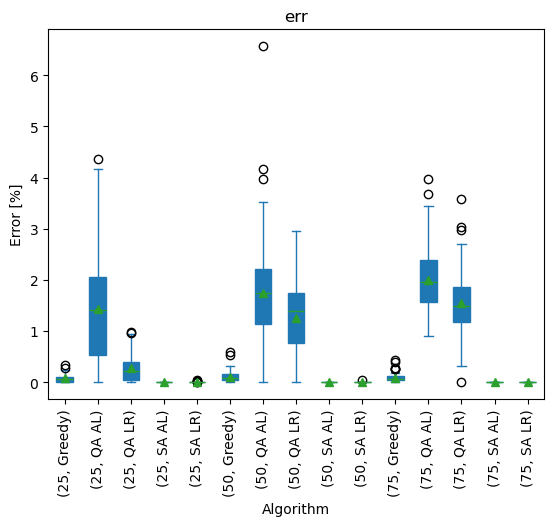

In [55]:
myFig = plt.figure()
ax = dff.plot.box(column='err', by=['density', 'algo'], xlabel='Algorithm', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)
plt.savefig('/home/roman/gitlab/densest-subgraph/paper_experiments/figs/err_QA_density.png')

<Figure size 640x480 with 0 Axes>

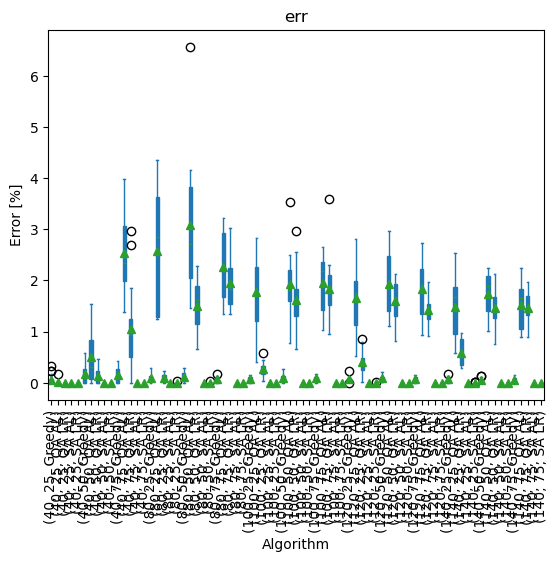

In [56]:
myFig = plt.figure()
ax = dff.plot.box(column='err', by=['n', 'density', 'algo'], xlabel='Algorithm', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)


In [57]:
dff.groupby('algo').count()

,index,instance,successful,optimum,target_cardinality_reached,edges_greedy,edges_algo,summary_g,summary_sampler_response_x,summary_sampler_response_value,...,details_algorithm,details_additional_info_g_for_greedy,err_greedy,size,step,max_iterations,number_of_iterations,details_additional_info_algo_summary_step,details_additional_info_algo_summary_max_iterations,details_additional_info_algo_summary_number_of_iterations
algo,,,,,,,,,,,,,,,,,,,,,
Greedy,225,225,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
QA AL,204,204,204,204,204,204,204,204,204,204,...,0,0,0,0,0,0,0,0,0,0
QA LR,225,225,225,225,225,225,225,225,225,225,...,0,0,0,0,0,0,0,0,0,0
SA AL,225,225,0,0,225,0,0,0,0,0,...,225,0,225,225,225,225,225,225,225,225
SA LR,225,225,0,0,225,0,0,0,0,0,...,225,25,225,225,0,0,0,0,0,0


In [58]:
folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results_Advantage2/{}/DwaveAlgoLinearToken'

n = [40, 80, 100, 120, 140, 160]

r = []
for i in n:
    file = folder.format(i)

    try:
        result = joblib.load(file)
        r.append(pd.DataFrame(get_result_data_omkar(result)))
    except:
        pass

df = pd.concat(r).reset_index(drop=True)
df = df[df['successful'] == True]


import re

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['n'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
#df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

df['optimum'] = df['n']*(df['n']-1)/2 - df['optimum']
df['edges_algo'] = df['n']*(df['n']-1)/2 - df['edges_algo']

df['err'] = 100*(df['edges_algo'] - df['optimum'])/df['optimum']

df['algo'] = 'QA LR'
df_lr_qa_T2 = df.copy()



In [59]:
df_lr_qa_T2.groupby('n').count()

,instance,successful,optimum,target_cardinality_reached,edges_greedy,edges_algo,summary_g,summary_sampler_response_x,summary_sampler_response_value,summary_sampler_response_cardinality,...,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_148,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_155,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_159,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_157,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_145,summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_146,density,k,err,algo
n,,,,,,,,,,,,,,,,,,,,,
40,45,45,45,45,45,45,45,45,45,45,...,0,0,0,0,0,0,45,45,45,45
80,45,45,45,45,45,45,45,45,45,45,...,0,0,0,0,0,0,45,45,45,45
100,45,45,45,45,45,45,45,45,45,45,...,0,0,0,0,0,0,45,45,45,45
120,45,45,45,45,45,45,45,45,45,45,...,0,0,0,0,0,0,45,45,45,45
140,40,40,40,40,40,40,40,40,40,40,...,0,0,0,0,0,0,40,40,40,40
160,14,14,14,14,14,14,14,14,14,14,...,14,14,14,14,14,14,14,14,14,14


<Figure size 640x480 with 0 Axes>

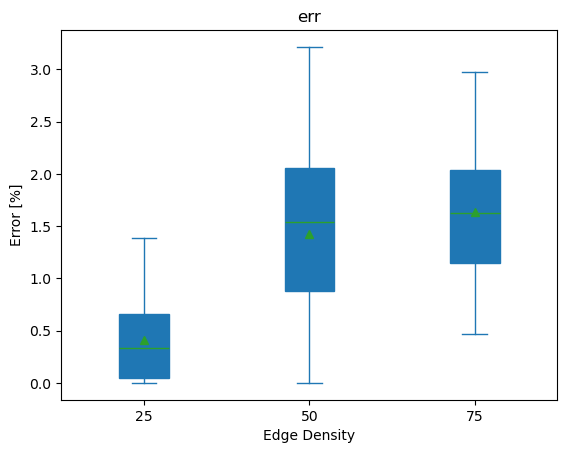

In [60]:
myFig = plt.figure()
ax = df_lr_qa_T2.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)


<Figure size 640x480 with 0 Axes>

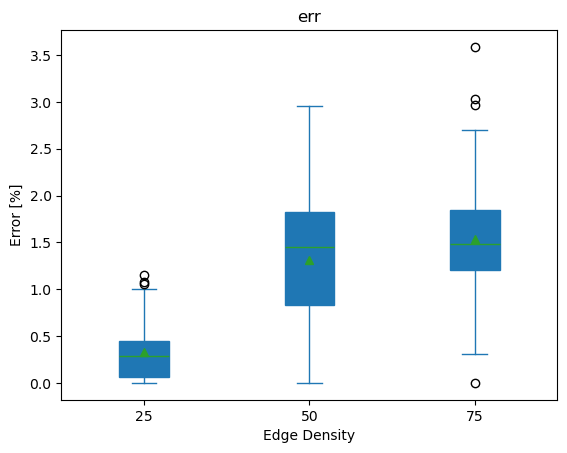

In [61]:
myFig = plt.figure()
ax = df_lr_qa_T1.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)


<Figure size 640x480 with 0 Axes>

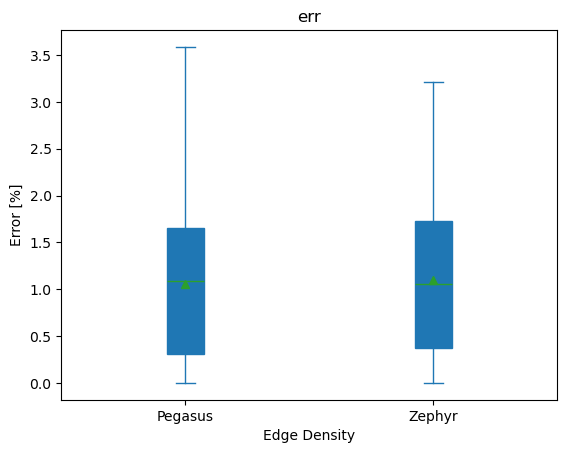

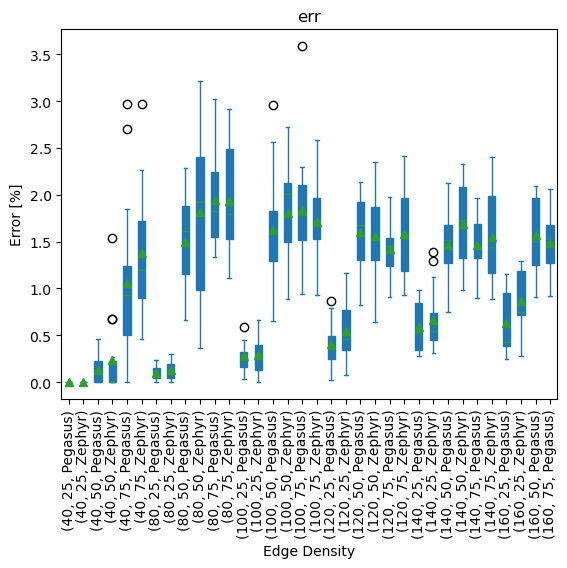

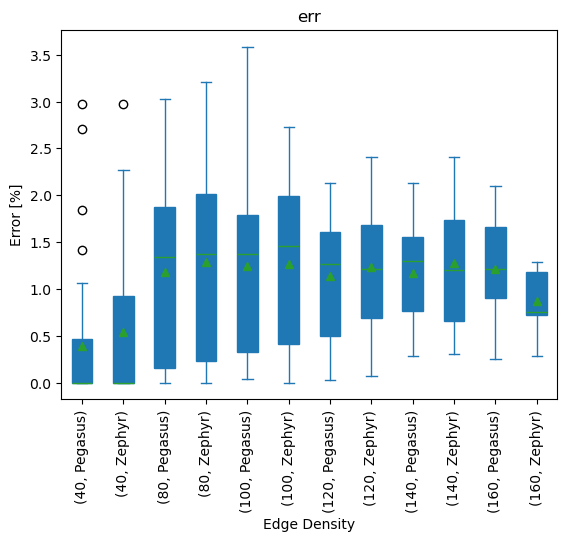

In [62]:
df_lr_qa_T1['topology'] = 'Pegasus'
df_lr_qa_T2['topology'] = 'Zephyr'

df_lr_qa = pd.concat([df_lr_qa_T1, df_lr_qa_T2]).reset_index(drop=True)

myFig = plt.figure()
ax = df_lr_qa.plot.box(column='err', by=['topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
ax = df_lr_qa.plot.box(column='err', by=['n', 'density', 'topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)
ax = df_lr_qa.plot.box(column='err', by=['n', 'topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)



In [63]:
#folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results/{}/DwaveAlgoAugementedLagrangianToken_no_clique_emb'
folder = '/home/roman/gitlab/omkar-sks/densest-subgraph/results_Advantage2/{}/DwaveAlgoAugementedLagrangianToken'

n = [40, 80, 100, 120, 140, 160]


r = []
for i in n:
    file = folder.format(i)

    try:
        result = joblib.load(file)
        r.append(pd.DataFrame(get_result_data_omkar(result)))
    except:
        pass

df = pd.concat(r)
df = df[df['successful'] == True].reset_index()


import re

s = df['instance'].apply(lambda x: re.findall(r'\d+', x)).tolist()
s = np.array(s, dtype='int')
df['n'] = s[:, 0]
df['density'] = 100-s[:, 1]
df['k'] = s[:, 2]
#df['is_target_cardinality'] = df['k']==df['result_qubo_cardinality']

df['optimum'] = df['n']*(df['n']-1)/2 - df['optimum']
df['edges_algo'] = df['n']*(df['n']-1)/2 - df['edges_algo']

df['err'] = 100*(df['edges_algo'] - df['optimum'])/df['optimum']

df['algo'] = 'QA AL'
df_al_qa_T2 = df.copy()



<Figure size 640x480 with 0 Axes>

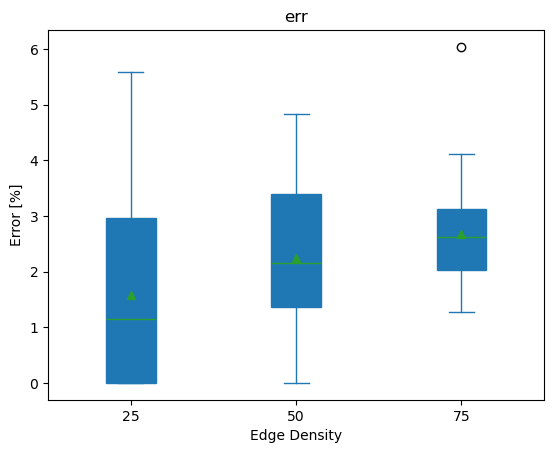

In [64]:
myFig = plt.figure()
ax = df_al_qa_T2.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)


<Figure size 640x480 with 0 Axes>

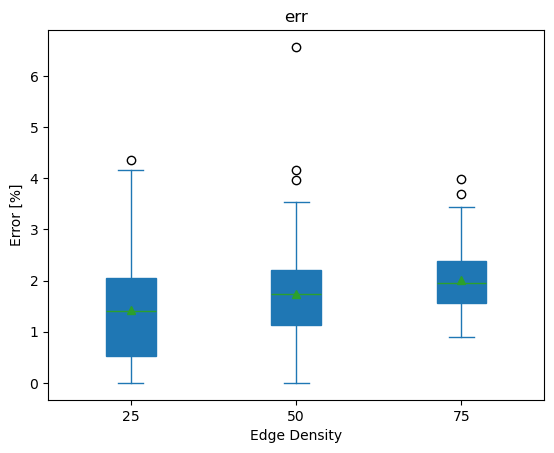

In [65]:
myFig = plt.figure()
ax = df_al_qa_T1.reset_index().plot.box(column='err', by='density', xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)


<Figure size 640x480 with 0 Axes>

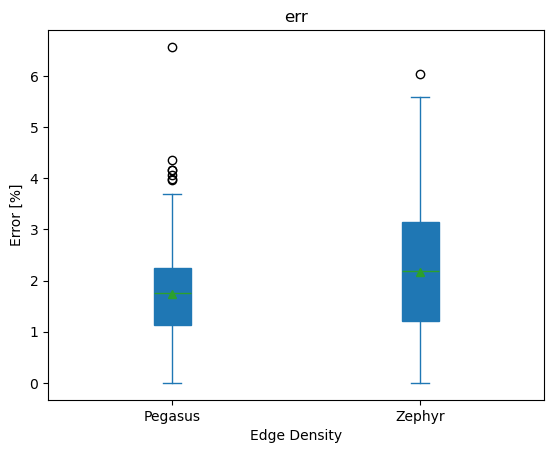

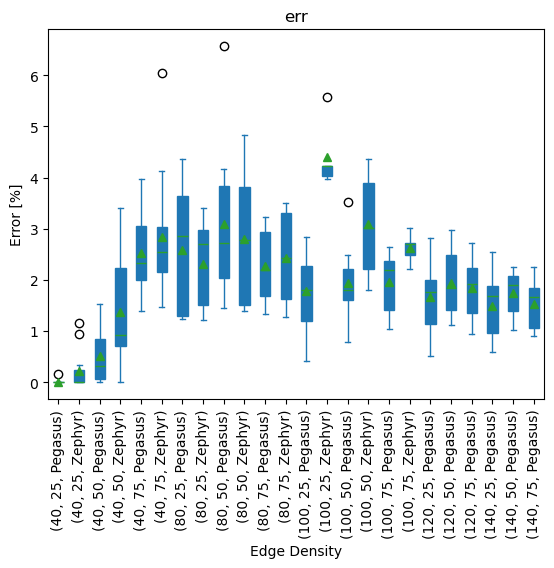

In [66]:
df_al_qa_T1['topology'] = 'Pegasus'
df_al_qa_T2['topology'] = 'Zephyr'

df_al_qa = pd.concat([df_al_qa_T1, df_al_qa_T2]).reset_index(drop=True)

myFig = plt.figure()
ax = df_al_qa.plot.box(column='err', by=['topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
ax = df_al_qa.plot.box(column='err', by=['n', 'density', 'topology',], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)



In [67]:
df_al_qa.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         31          31       31                          31   
         100        42          42       42                          42   
         120        43          43       43                          43   
         140        43          43       43                          43   
Zephyr   40         45          45       45                          45   
         80         29          29       29                          29   
         100        19          19       19                          19   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             31          31         31                          31   
         100            42          42         42                          42   
         120            43          43         43                          43   
         140            43          43         43                          43   
Zephyr   40             45          45         45                          45   
         80             29          29         29                          29   
         100            19          19         19                          19   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               31   
         100                              42   
         120                              43   
         140                              43   
Zephyr   40                               45   
         80                               29   
         100                              19   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     31  ...   
         100                                    42  ...   
         120                                    43  ...   
         140                                    43  ...   
Zephyr   40                                     45  ...   
         80                                     29  ...   
         100                                    19  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_90  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80                                                   0                                         
         100                                                  0                                         
         120                                                  0                                         
         140                                                  0                                         
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_91  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80   

In [68]:
df_al_qa_T1.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         31          31       31                          31   
         100        42          42       42                          42   
         120        43          43       43                          43   
         140        43          43       43                          43   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             31          31         31                          31   
         100            42          42         42                          42   
         120            43          43         43                          43   
         140            43          43         43                          43   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               31   
         100                              42   
         120                              43   
         140                              43   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     31  ...   
         100                                    42  ...   
         120                                    43  ...   
         140                                    43  ...   

              algo_summary_best_computed_cardinality_x  \
topology n                                               
Pegasus  40                                          0   
         80                                          0   
         100                                         0   
         120                                         0   
         140                                         0   

              algo_summary_initial_lambda  algo_summary_lambdai  \
topology n                                                        
Pegasus  40                             0                     0   
         80                             0                     0   
         100                            0                     0   
         120                            0                     0   
         140                            0                     0   

              algo_summary_step  algo_summary_max_iterations  \
topology n                                                     
Pegasus  40                   0                            0   
         80                   0                            0   
         100                  0                            0   
         120                  0                            0   
         140                  0                            0   

              algo_summary_number_of_iterations  algo  density   k  err  
topology n                                                               
Pegasus  40                                   0    45       45  45   45  
         80                                   0    31       31  31   31  
         100                                  0    42       42  42   42  
         120                                  0    43       43  43   43  
         140                                  0    43       43  43   43  

[5 rows x 367 columns]

In [69]:
df_al_qa_T2.groupby(['topology', 'n']).count()

index  instance  successful  optimum  \
topology n                                           
Zephyr   40      45        45          45       45   
         80      29        29          29       29   
         100     19        19          19       19   

              target_cardinality_reached  edges_greedy  edges_algo  summary_g  \
topology n                                                                      
Zephyr   40                           45            45          45         45   
         80                           29            29          29         29   
         100                          19            19          19         19   

              summary_sampler_response_x  summary_sampler_response_value  ...  \
topology n                                                                ...   
Zephyr   40                           45                              45  ...   
         80                           29                              29  ...   
         100                          19                              19  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_94  \
topology n                                                                                              
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_95  \
topology n                                                                                              
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_96  \
topology n                                                                                              
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_97  \
topology n                                                                                              
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_98  \
topology n                                                                                              
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_99  \
topology n                                                                                              
Zephyr   40                                                   0                            

In [70]:
df_al_qa.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         31          31       31                          31   
         100        42          42       42                          42   
         120        43          43       43                          43   
         140        43          43       43                          43   
Zephyr   40         45          45       45                          45   
         80         29          29       29                          29   
         100        19          19       19                          19   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             31          31         31                          31   
         100            42          42         42                          42   
         120            43          43         43                          43   
         140            43          43         43                          43   
Zephyr   40             45          45         45                          45   
         80             29          29         29                          29   
         100            19          19         19                          19   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               31   
         100                              42   
         120                              43   
         140                              43   
Zephyr   40                               45   
         80                               29   
         100                              19   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     31  ...   
         100                                    42  ...   
         120                                    43  ...   
         140                                    43  ...   
Zephyr   40                                     45  ...   
         80                                     29  ...   
         100                                    19  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_90  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80                                                   0                                         
         100                                                  0                                         
         120                                                  0                                         
         140                                                  0                                         
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_91  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80   

In [71]:
df_lr_qa.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        45          45       45                          45   
         160        43          43       43                          43   
Zephyr   40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        40          40       40                          40   
         160        14          14       14                          14   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            45          45         45                          45   
         160            43          43         43                          43   
Zephyr   40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            40          40         40                          40   
         160            14          14         14                          14   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              45   
         160                              43   
Zephyr   40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              40   
         160                              14   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    45  ...   
         160                                    43  ...   
Zephyr   40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    40  ...   
         160                                    14  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_156  \
topology n                                                                                             
Pegasus  40                                                   0                                        
         80     

In [72]:
df_lr_qa['topology']

0      Pegasus
1      Pegasus
2      Pegasus
3      Pegasus
4      Pegasus
        ...   
497     Zephyr
498     Zephyr
499     Zephyr
500     Zephyr
501     Zephyr
Name: topology, Length: 502, dtype: object

In [73]:
mask_pegasus = df_lr_qa['topology'] == 'Pegasus'
mask_zephyr = df_lr_qa['topology']== 'Zephyr'

#set(df_lr_qa[mask]['instance'])

common_instances = set(df_lr_qa[mask_pegasus]['instance']).intersection(set(df_lr_qa[mask_zephyr]['instance']))

df_lr_qa_common_instances = df_lr_qa[df_lr_qa['instance'].isin(common_instances)].reset_index(drop=True)

In [74]:
df_lr_qa_common_instances.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        40          40       40                          40   
         160        14          14       14                          14   
Zephyr   40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        40          40       40                          40   
         160        14          14       14                          14   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            40          40         40                          40   
         160            14          14         14                          14   
Zephyr   40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            40          40         40                          40   
         160            14          14         14                          14   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              40   
         160                              14   
Zephyr   40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              40   
         160                              14   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    40  ...   
         160                                    14  ...   
Zephyr   40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    40  ...   
         160                                    14  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_156  \
topology n                                                                                             
Pegasus  40                                                   0                                        
         80     

In [75]:
df_lr_qa.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        45          45       45                          45   
         160        43          43       43                          43   
Zephyr   40         45          45       45                          45   
         80         45          45       45                          45   
         100        45          45       45                          45   
         120        45          45       45                          45   
         140        40          40       40                          40   
         160        14          14       14                          14   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            45          45         45                          45   
         160            43          43         43                          43   
Zephyr   40             45          45         45                          45   
         80             45          45         45                          45   
         100            45          45         45                          45   
         120            45          45         45                          45   
         140            40          40         40                          40   
         160            14          14         14                          14   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              45   
         160                              43   
Zephyr   40                               45   
         80                               45   
         100                              45   
         120                              45   
         140                              40   
         160                              14   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    45  ...   
         160                                    43  ...   
Zephyr   40                                     45  ...   
         80                                     45  ...   
         100                                    45  ...   
         120                                    45  ...   
         140                                    40  ...   
         160                                    14  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_primary_emb_156  \
topology n                                                                                             
Pegasus  40                                                   0                                        
         80     

<Figure size 640x480 with 0 Axes>

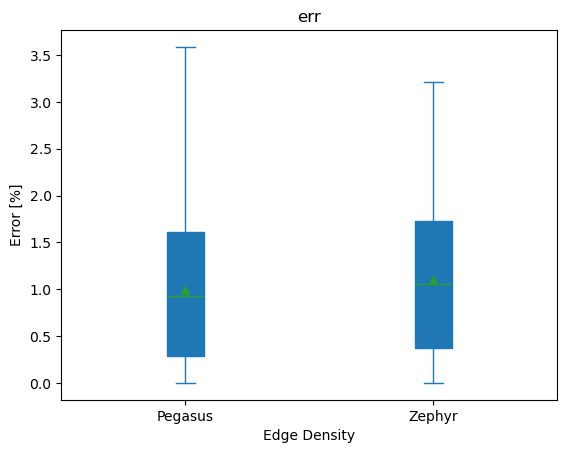

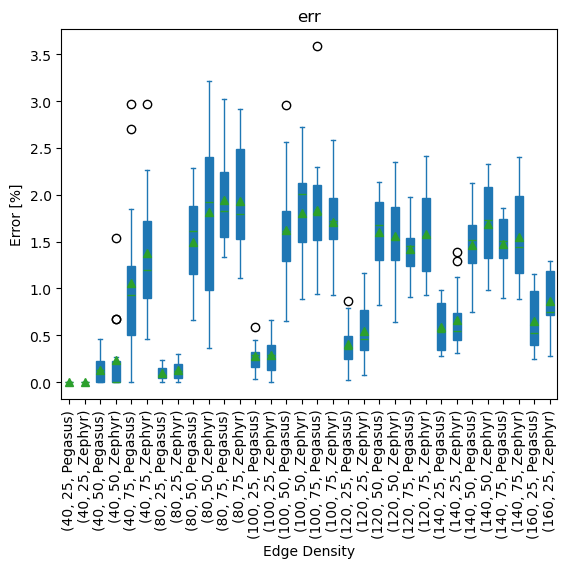

In [76]:
myFig = plt.figure()
ax = df_lr_qa_common_instances.plot.box(column='err', by=['topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
ax = df_lr_qa_common_instances.plot.box(column='err', by=['n', 'density', 'topology',], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)


In [77]:
mask_pegasus = df_al_qa['topology'] == 'Pegasus'
mask_zephyr = df_al_qa['topology']== 'Zephyr'

#set(df_lr_qa[mask]['instance'])

common_instances = set(df_al_qa[mask_pegasus]['instance']).intersection(set(df_al_qa[mask_zephyr]['instance']))

df_al_qa_common_instances = df_al_qa[df_al_qa['instance'].isin(common_instances)].reset_index(drop=True)

In [78]:
df_al_qa_common_instances.groupby(['topology', 'n']).count()

instance  successful  optimum  target_cardinality_reached  \
topology n                                                                
Pegasus  40         45          45       45                          45   
         80         15          15       15                          15   
         100        19          19       19                          19   
Zephyr   40         45          45       45                          45   
         80         15          15       15                          15   
         100        19          19       19                          19   

              edges_greedy  edges_algo  summary_g  summary_sampler_response_x  \
topology n                                                                      
Pegasus  40             45          45         45                          45   
         80             15          15         15                          15   
         100            19          19         19                          19   
Zephyr   40             45          45         45                          45   
         80             15          15         15                          15   
         100            19          19         19                          19   

              summary_sampler_response_value  \
topology n                                     
Pegasus  40                               45   
         80                               15   
         100                              19   
Zephyr   40                               45   
         80                               15   
         100                              19   

              summary_sampler_response_cardinality  ...  \
topology n                                          ...   
Pegasus  40                                     45  ...   
         80                                     15  ...   
         100                                    19  ...   
Zephyr   40                                     45  ...   
         80                                     15  ...   
         100                                    19  ...   

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_90  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80                                                   0                                         
         100                                                  0                                         
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_91  \
topology n                                                                                              
Pegasus  40                                                   0                                         
         80                                                   0                                         
         100                                                  0                                         
Zephyr   40                                                   0                                         
         80                                                   0                                         
         100                                                 19                                         

              summary_additional_info_algo_summary_method_provided_embedding_summary_secondary_emb_92  \
topology n                                                                                              
Pegasus  40   

<Figure size 640x480 with 0 Axes>

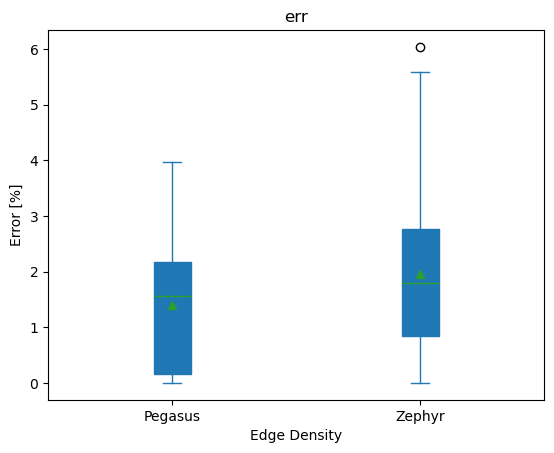

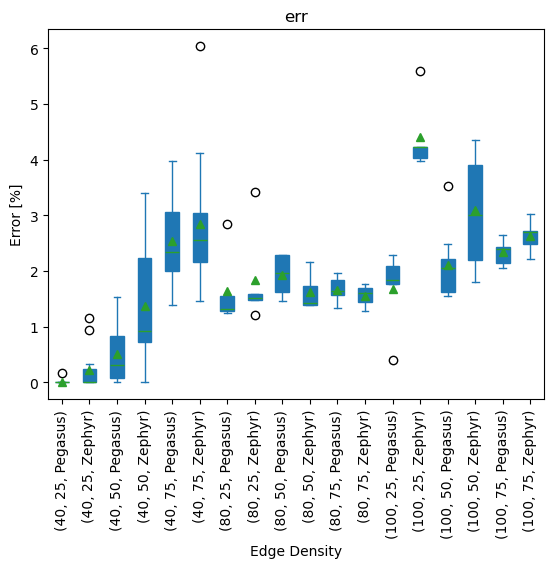

In [79]:
myFig = plt.figure()
ax = df_al_qa_common_instances.plot.box(column='err', by=['topology'], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True)
ax = df_al_qa_common_instances.plot.box(column='err', by=['n', 'density', 'topology',], xlabel='Edge Density', ylabel='Error [%]', logy=False, showmeans=True, patch_artist=True, rot=90)
